# Renewables in Electricity Markets: System Perspective

This is the solution to Assignment 1 proposed in the course "Renewables in Electricity Markets" from DTU in 2025.

The chosen system is the IEEE 24-bus test reliability system, shown in the figure below. Data is in the file IEEE 24-bus reliability test system - data.xlsx. 

# ![System](img/System.png)

## Step 3: Network Constraints

This step includes the network topology instead of a single bus.

### Input data

In [1]:
# Import the libraries to be used
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import linopy
np.random.seed(42)

#### Read data

In [2]:
# system data
data = pd.read_excel('data/IEEE 24-bus reliability test system - data.xlsx', sheet_name=None)
print(data.keys())

dict_keys(['Generators', 'Costs', 'SystemLoadProfile', 'LoadDist', 'BidTypes', 'Lines', 'WindFarms', 'LineModification'])


In [3]:
#dict_keys(['Generators', 'Costs', 'SystemLoadProfile', 'LoadDist', 'BidTypes', 'Lines', 'WindFarms', 'LineModification'])
generators = data['Generators']
costs = data['Costs']
load_profile = data['SystemLoadProfile']
load_dist = data['LoadDist']
load_bid_types = data['BidTypes']
lines = data['Lines']
wind_farms = data['WindFarms']
line_modification = data['LineModification']

In [4]:
# windfarm data
wind_production_dk = pd.read_csv('data/ninja_wind_55.4104_12.3039_corrected.csv', skiprows=3)

#### Handle demand data

In [5]:
# Assign demand to each bus based on the load distribution
demand = load_profile.merge(load_dist, how='cross')
demand['Demand_MW'] = demand['System_demand_MW'] * demand['Percent_of_system_load'] / 100
demand['Hour'] = demand['Hour'] -1  # Adjust hour to be 0-indexed
demand.drop(columns=['System_demand_MW', 'Percent_of_system_load'], inplace=True)

In [6]:
# create demand bids: Load (id), Node (id), Quantity (MW), Price ($/MWh)
demand_bid = demand.merge(load_bid_types, left_on='Load_type', right_on='Load_type', how='left')
demand_bid['Quantity_MW'] = demand_bid['Demand_MW']*demand_bid['Quantity_perc']/100
demand_bid = demand_bid[['Bid', 'Load', 'Node', 'Hour', 'Load_type', 'Quantity_MW', 'Price_$/MWh']]
demand_bid['Load'] = 'L' + demand_bid['Load'].astype(str) 

#### Handle WindFarm data

In [7]:
#select 6 random days to simulate the wind production of each generator
np.random.seed(42)
wind_production_dk['local_time'] = pd.to_datetime(wind_production_dk['local_time'])
wind_production_dk['day'] = wind_production_dk['local_time'].dt.date
random_days = np.random.choice(wind_production_dk['day'].unique(), size=len(wind_farms), replace=False)
wind_production_sample = wind_production_dk[wind_production_dk['day'].isin(random_days)]
# assign one day to one zone windfarm
wind_production_sample['WindFarm'] = wind_production_sample['day'].apply(lambda x: random_days.tolist().index(x)+1)
wind_production_sample['Hour'] = wind_production_sample['local_time'].dt.hour

In [8]:
wind_forecast_generation = wind_production_sample.merge(wind_farms, on='WindFarm', how='left')
wind_forecast_generation['Generation_MW'] = wind_forecast_generation['Installed_Capacity_MW'] * wind_forecast_generation['electricity']
wind_forecast_generation = wind_forecast_generation[['WindFarm', 'Node', 'Hour', 'Generation_MW']].sort_values(['WindFarm', 'Hour'])
wind_forecast_generation['WindFarm'] = 'W' + wind_forecast_generation['WindFarm'].astype(str)
wind_forecast_generation.rename(columns={'Generation_MW': 'PForecast_MW', 'WindFarm': 'Unit'}, inplace=True)

#### Handle supply data

In [9]:
gen_constraints = generators.merge(costs, on='Unit')
gen_constraints['Unit'] = 'G' + gen_constraints['Unit'].astype(str)

### Modelling

#### Model 1. Market clearing with Nodal Prices 

In the base case we consider a DC power flow model, which is a linear approximation of the AC power flow equations. The market clearing is done per node. 

In [10]:

def build_and_solve_market_clearing(gen_constraints, demand_bid, wind_forecast_generation, lines):

    # Sets
    generators_set = pd.Index(gen_constraints['Unit'].unique(), name='Unit')
    wind_farms_set = pd.Index(wind_forecast_generation['Unit'].unique(), name='Unit')
    hours_set = pd.RangeIndex(0, 24, name='Hour')
    loads_set = pd.Index(demand_bid['Load'].unique(), name='Load')
    bids_set = pd.Index(demand_bid['Bid'].unique(), name='Bid')
    nodes_set = pd.RangeIndex(1, 25, name='Node')
    lines_set = pd.Index(lines['Line'].unique(), name='Line')


    # Parameters
    gen_constraints_xr = gen_constraints.set_index(['Unit']).to_xarray()
    demand_bid_xr = demand_bid.set_index(['Load','Bid','Hour']).to_xarray()
    wind_forecast_xr = wind_forecast_generation.set_index(['Unit','Hour']).to_xarray()
    lines_xr = lines.set_index('Line').to_xarray()

    pmax = gen_constraints_xr['Pmax_MW'] # Maximum power output of each generator in MW
    ci = gen_constraints_xr['Ci_$/MWh'] # Variable cost of each generator in $/MWh

    wind_forecast = wind_forecast_xr['PForecast_MW'] # Forecasted power output of each wind farm in MW

    demand_quantity = demand_bid_xr['Quantity_MW'].reindex(
        Load=loads_set, 
        Node=nodes_set,
        Bid=bids_set, 
        Hour=hours_set
    ).fillna(0)

    demand_price = demand_bid_xr['Price_$/MWh'].reindex(
        Load=loads_set, 
        Node=nodes_set,
        Bid=bids_set,
        Hour=hours_set
    ).fillna(0)

    line_capacity = lines_xr['Capacity_MVA']
    line_reactance = lines_xr['Reactance_pu']
    from_node = lines_xr['From']
    to_node = lines_xr['To']

    m = linopy.Model()

    # ── Decision Variables ──────────────────────────────────────────────────────

    # Generator dispatch [MW]
    p_gen = m.add_variables(
        lower=0,
        coords=[generators_set, hours_set],
        name="p_gen"
    )

    # Wind dispatch [MW]
    p_wind = m.add_variables(
        lower=0,
        coords=[wind_farms_set, hours_set],
        name="p_wind"
    )

    # Demand served per bid [MW]
    p_demand = m.add_variables(
        lower=0,
        coords=[loads_set, bids_set, hours_set],
        name="p_demand"
    )

    # Voltage angles [rad] — reference node fixed later
    theta = m.add_variables(
        coords=[nodes_set, hours_set],
        name="theta"
    )

    # Line flow [MW]
    p_line = m.add_variables(
        coords=[lines_set, hours_set],
        name="p_line"
    )

    # ── Objective: Maximise Social Welfare ──────────────────────────────────────
    # Revenue from demand bids minus generation costs

    revenue   = (demand_price  * p_demand).sum()
    gen_cost  = (ci            * p_gen   ).sum()

    m.objective = -(revenue - gen_cost)   # linopy minimises → negate for max

    # ── Constraints ─────────────────────────────────────────────────────────────

    # 1. Generator capacity limits
    m.add_constraints(
        p_gen <= pmax,
        name="gen_pmax"
    )

    m.add_constraints(
        p_gen >= 0,
        name="gen_pmin"
    )

    # 2. Wind curtailment limit (cannot exceed forecast)
    m.add_constraints(
        p_wind <= wind_forecast,
        name="wind_pmax"
    )

    # 3. Demand bid quantity limits
    m.add_constraints(
        p_demand <= demand_quantity,
        name="demand_limit"
    )

    # 4. DC line flow definition:  p_line = (θ_from − θ_to) / x

    for line in lines_set:
        f = from_node.sel(Line=line)
        t = to_node.sel(Line=line)
        x = float(line_reactance.sel(Line=line))

        m.add_constraints(
            p_line.sel(Line=line) - (theta.sel(Node=f) - theta.sel(Node=t)) / x == 0,
            name=f"dc_flow_{line}"
        )

    # 5. Line capacity limits
    m.add_constraints(
        p_line <= line_capacity,
        name="line_capacity_pos"
    )

    m.add_constraints(
        p_line >= -line_capacity,
        name="line_capacity_neg"
    )

    # 6. Nodal power balance  (injection = withdrawal)
    #    Build injection / withdrawal maps indexed by Node


    for node in nodes_set:
        # Supply at this node
        gens_at_node  = gen_constraints_xr.where(gen_constraints_xr['Node'] == node, drop=True).indexes['Unit'].to_list()
        winds_at_node = wind_forecast_xr.where(wind_forecast_xr['Node'] == node, drop=True).indexes['Unit'].to_list()
        loads_at_node = demand_bid_xr.where(demand_bid_xr['Node'] == node, drop=True).indexes['Load'].to_list()

        supply = (
            (p_gen .sel(Unit=gens_at_node) .sum("Unit") if gens_at_node  else 0)
            + (p_wind.sel(Unit=winds_at_node).sum("Unit") if winds_at_node else 0)
        )

        demand_served = (
            p_demand.sel(Load=loads_at_node).sum(["Load", "Bid"])
            if loads_at_node else 0
        )

        # Net line injections into this node
        lines_from = [l for l in lines_set if from_node.sel(Line=l) == node]
        lines_to   = [l for l in lines_set if to_node.sel(Line=l)   == node]

        net_flow = (
            (p_line.sel(Line=lines_to  ).sum("Line") if lines_to   else 0)
            - (p_line.sel(Line=lines_from).sum("Line") if lines_from else 0)
        )

        m.add_constraints(
            supply + net_flow - demand_served == 0,
            name=f"balance_node_{node}"
        )

    # 7. Reference angle  (slack bus — fix node 13)
    m.add_constraints(
        theta.sel(Node=13) == 0,
        name="slack_bus"
    )

    # ── Solve ────────────────────────────────────────────────────────────────────
    m.solve(solver_name="highs")   # or "glpk", "gurobi", etc.

    return m

In [11]:
model1 = build_and_solve_market_clearing(gen_constraints, demand_bid, wind_forecast_generation, lines)

Running HiGHS 1.13.1 (git hash: 1d267d9): Copyright (c) 2026 under MIT licence terms
LP linopy-problem-ns9tprrq has 5400 rows; 3456 cols; 10152 nonzeros
Coefficient ranges:
  Matrix  [1e+00, 9e+01]
  Cost    [5e+00, 2e+03]
  Bound   [0e+00, 0e+00]
  RHS     [1e+00, 1e+03]
Presolving model
1344 rows, 2832 cols, 5400 nonzeros  0s
772 rows, 2260 cols, 4777 nonzeros  0s
Dependent equations search running on 717 equations with time limit of 1000.00s
Dependent equations search removed 0 rows and 0 nonzeros in 0.00s (limit = 1000.00s)
717 rows, 2205 cols, 4776 nonzeros  0s
Presolve reductions: rows 717(-4683); columns 2205(-1251); nonzeros 4776(-5376) 
Solving the presolved LP
Using dual simplex solver
  Iteration        Objective     Infeasibilities num(sum)
          0    -1.5229215945e-09 Ph1: 16(18225.7); Du: 0(2.00548e-12) 0.0s
        754    -9.0998206670e+07 Pr: 0(0); Du: 0(3.73035e-14) 0.0s

Performed postsolve
Solving the original LP from the solution after postsolve

Model name     

#### Model 2. Line sensitivity

In this section we modify the lines reducing the capacity of some of them.

In [12]:
# Additional modifications: reduce to a factor the lines going from zone 1 (nodes 1 to 10) to zone 2 (nodes 11 to 24)
reduction_factor = 3
lines_to_modify = lines[((lines['From'] <= 10) & (lines['To'] >= 11))].copy()
lines_to_modify['Modified_Capacity_MW'] = (lines_to_modify['Capacity_MVA'] / reduction_factor).astype(int)
additional_modifications = lines_to_modify.drop(columns=['Reactance_pu','Line']).rename(columns={'Capacity_MVA': 'Original_Capacity_MW'})
modifications = pd.concat([line_modification, additional_modifications], ignore_index=True)
modifications

,From,To,Original_Capacity_MW,Modified_Capacity_MW
0,15,21,1000,400
1,14,16,500,250
2,13,23,500,250
3,3,24,400,133
4,9,11,400,133
5,9,12,400,133
6,10,11,400,133
7,10,12,400,133


In [13]:
# modify lines using from and to
lines_modified = lines.copy()
lines_modified.set_index(['From', 'To'], inplace=True)
modifications.set_index(['From', 'To'], inplace=True)
# replace Capacity_MVA with Modified_Capacity_MW where applicable
for idx, row in modifications.iterrows():
    from_node = idx[0]
    to_node = idx[1]
    if (from_node, to_node) in lines_modified.index:
        lines_modified.loc[(from_node, to_node), 'Capacity_MVA'] = row['Modified_Capacity_MW']
lines_modified.reset_index(inplace=True)

In [14]:
model2 = build_and_solve_market_clearing(gen_constraints, demand_bid, wind_forecast_generation, lines_modified)

Running HiGHS 1.13.1 (git hash: 1d267d9): Copyright (c) 2026 under MIT licence terms
LP linopy-problem-az_zp2tp has 5400 rows; 3456 cols; 10152 nonzeros
Coefficient ranges:
  Matrix  [1e+00, 9e+01]
  Cost    [5e+00, 2e+03]
  Bound   [0e+00, 0e+00]
  RHS     [1e+00, 1e+03]
Presolving model
1344 rows, 2832 cols, 5400 nonzeros  0s
726 rows, 2214 cols, 4694 nonzeros  0s
Dependent equations search running on 653 equations with time limit of 1000.00s
Dependent equations search removed 0 rows and 0 nonzeros in 0.00s (limit = 1000.00s)
653 rows, 2141 cols, 4714 nonzeros  0s
Presolve reductions: rows 653(-4747); columns 2141(-1315); nonzeros 4714(-5438) 
Solving the presolved LP
Using dual simplex solver
  Iteration        Objective     Infeasibilities num(sum)
          0     2.3936322288e-09 Ph1: 35(41594.6); Du: 0(3.47412e-12) 0.0s
        796    -9.0923865700e+07 Pr: 0(0) 0.0s

Performed postsolve
Solving the original LP from the solution after postsolve

Model name          : linopy-proble

In [15]:
print(f"Model 1 objective value (social welfare): {-model1.objective.value:,.2f} $")
print(f"Model 2 objective value (social welfare): {-model2.objective.value:,.2f} $")

Model 1 objective value (social welfare): 90,998,206.67 $
Model 2 objective value (social welfare): 90,923,865.70 $


In [16]:
is_congested_m1 = bool((model1.constraints['line_capacity_pos'].dual!=0).any()) or bool((model1.constraints['line_capacity_neg'].dual!=0).any())
is_congested_m2 = bool((model2.constraints['line_capacity_pos'].dual!=0).any()) or bool((model2.constraints['line_capacity_neg'].dual!=0).any())

print(f"Is there congestion in Model 1? {'Yes' if is_congested_m1 else 'No'}")
print(f"Is there congestion in Model 2? {'Yes' if is_congested_m2 else 'No'}")

Is there congestion in Model 1? No
Is there congestion in Model 2? Yes


#### Model 3. Zonal prices

Here we will consider that all nodes in the system are grouped into two zones: zone 1 (nodes 1 to 10) and zone 2 (nodes 11 to 24). The capacity of the lines connecting the two zones is the sum of the capacity of the lines connecting the nodes in zone 1 to the nodes in zone 2. Now, we don't consider any power flow restrictions, only the total capacity of the lines connecting the two zones.

In [17]:
#zone_lines
line_capacity_between_zones = lines_modified[(lines_modified['From'] <= 10) & (lines_modified['To'] >= 11)]['Capacity_MVA'].sum()

In [18]:
def build_and_solve_market_clearing_with_zones(gen_constraints, demand_bid, wind_forecast_generation, line_capacity_between_zones):

    # Sets
    generators_set = pd.Index(gen_constraints['Unit'].unique(), name='Unit')
    wind_farms_set = pd.Index(wind_forecast_generation['Unit'].unique(), name='Unit')
    hours_set = pd.RangeIndex(0, 24, name='Hour')
    loads_set = pd.Index(demand_bid['Load'].unique(), name='Load')
    bids_set = pd.Index(demand_bid['Bid'].unique(), name='Bid')
    nodes_set = pd.RangeIndex(1, 25, name='Node')
    lines_set = pd.Index(lines['Line'].unique(), name='Line')


    # Parameters
    gen_constraints_xr = gen_constraints.set_index(['Unit']).to_xarray()
    demand_bid_xr = demand_bid.set_index(['Load','Bid','Hour']).to_xarray()
    wind_forecast_xr = wind_forecast_generation.set_index(['Unit','Hour']).to_xarray()
    lines_xr = lines.set_index('Line').to_xarray()

    pmax = gen_constraints_xr['Pmax_MW'] # Maximum power output of each generator in MW
    ci = gen_constraints_xr['Ci_$/MWh'] # Variable cost of each generator in $/MWh

    wind_forecast = wind_forecast_xr['PForecast_MW'] # Forecasted power output of each wind farm in MW

    demand_quantity = demand_bid_xr['Quantity_MW'].reindex(
        Load=loads_set, 
        Node=nodes_set,
        Bid=bids_set, 
        Hour=hours_set
    ).fillna(0)

    demand_price = demand_bid_xr['Price_$/MWh'].reindex(
        Load=loads_set, 
        Node=nodes_set,
        Bid=bids_set,
        Hour=hours_set
    ).fillna(0)

    m = linopy.Model()

    # ── Decision Variables ──────────────────────────────────────────────────────

    # Generator dispatch [MW]
    p_gen = m.add_variables(
        lower=0,
        coords=[generators_set, hours_set],
        name="p_gen"
    )

    # Wind dispatch [MW]
    p_wind = m.add_variables(
        lower=0,
        coords=[wind_farms_set, hours_set],
        name="p_wind"
    )

    # Demand served per bid [MW]
    p_demand = m.add_variables(
        lower=0,
        coords=[loads_set, bids_set, hours_set],
        name="p_demand"
    )


    # Line flow [MW]
    p_line = m.add_variables(
        coords=[hours_set],
        name="p_line"
    )

    # ── Objective: Maximise Social Welfare ──────────────────────────────────────
    # Revenue from demand bids minus generation costs

    revenue   = (demand_price  * p_demand).sum()
    gen_cost  = (ci            * p_gen   ).sum()

    m.objective = -(revenue - gen_cost)   # linopy minimises → negate for max

    # ── Constraints ─────────────────────────────────────────────────────────────

    # 1. Generator capacity limits
    m.add_constraints(
        p_gen <= pmax,
        name="gen_pmax"
    )

    m.add_constraints(
        p_gen >= 0,
        name="gen_pmin"
    )

    # 2. Wind curtailment limit (cannot exceed forecast)
    m.add_constraints(
        p_wind <= wind_forecast,
        name="wind_pmax"
    )

    # 3. Demand bid quantity limits
    m.add_constraints(
        p_demand <= demand_quantity,
        name="demand_limit"
    )

    # 4. Line capacity limits
    m.add_constraints(
        p_line <= line_capacity_between_zones,
        name="line_capacity_pos"
    )

    m.add_constraints(
        p_line >= -line_capacity_between_zones,
        name="line_capacity_neg"
    )

    # 6. Nodal power balance  (injection = withdrawal)
    #    Build injection / withdrawal maps indexed by Node

    # Zone 1
    # Supply and demand at this zone
    gens_at_zone1  = gen_constraints_xr.where(gen_constraints_xr['Node'] <= 10, drop=True).indexes['Unit'].to_list()
    winds_at_zone1 = wind_forecast_xr.where(wind_forecast_xr['Node'] <= 10, drop=True).indexes['Unit'].to_list()
    loads_at_zone1 = demand_bid_xr.where(demand_bid_xr['Node'] <= 10, drop=True).indexes['Load'].to_list()

    supply_zone1 = (
        (p_gen .sel(Unit=gens_at_zone1) .sum("Unit") if gens_at_zone1  else 0)
        + (p_wind.sel(Unit=winds_at_zone1).sum("Unit") if winds_at_zone1 else 0)
    )

    demand_served_zone1 = (
        p_demand.sel(Load=loads_at_zone1).sum(["Load", "Bid"])
        if loads_at_zone1 else 0
    )

    m.add_constraints(
        supply_zone1 - p_line - demand_served_zone1 == 0,
        name=f"balance_zone1"
    )

    # Zone 2
    # Supply and demand at this zone
    gens_at_zone2  = gen_constraints_xr.where(gen_constraints_xr['Node'] > 10, drop=True).indexes['Unit'].to_list()
    winds_at_zone2 = wind_forecast_xr.where(wind_forecast_xr['Node'] > 10, drop=True).indexes['Unit'].to_list()
    loads_at_zone2 = demand_bid_xr.where(demand_bid_xr['Node'] > 10, drop=True).indexes['Load'].to_list()

    supply_zone2 = (
        (p_gen .sel(Unit=gens_at_zone2) .sum("Unit") if gens_at_zone2  else 0)
        + (p_wind.sel(Unit=winds_at_zone2).sum("Unit") if winds_at_zone2 else 0)
    )

    demand_served_zone2 = (
        p_demand.sel(Load=loads_at_zone2).sum(["Load", "Bid"])
        if loads_at_zone2 else 0
    )

    m.add_constraints(
        supply_zone2 + p_line - demand_served_zone2 == 0,
        name=f"balance_zone2"
    )


    # ── Solve ────────────────────────────────────────────────────────────────────
    m.solve(solver_name="highs")   # or "glpk", "gurobi", etc.

    return m

In [19]:
model3 = build_and_solve_market_clearing_with_zones(gen_constraints, demand_bid, wind_forecast_generation, line_capacity_between_zones)

Running HiGHS 1.13.1 (git hash: 1d267d9): Copyright (c) 2026 under MIT licence terms
LP linopy-problem-f94d5st_ has 2448 rows; 2088 cols; 4512 nonzeros
Coefficient ranges:
  Matrix  [1e+00, 1e+00]
  Cost    [5e+00, 2e+03]
  Bound   [0e+00, 0e+00]
  RHS     [1e+00, 7e+02]
Presolving model
48 rows, 1536 cols, 1560 nonzeros  0s
48 rows, 504 cols, 528 nonzeros  0s
Dependent equations search running on 48 equations with time limit of 1000.00s
Dependent equations search removed 0 rows and 0 nonzeros in 0.00s (limit = 1000.00s)
48 rows, 504 cols, 528 nonzeros  0s
Presolve reductions: rows 48(-2400); columns 504(-1584); nonzeros 528(-3984) 
Solving the presolved LP
Using dual simplex solver
  Iteration        Objective     Infeasibilities num(sum)
          0     0.0000000000e+00 Ph1: 0(0) 0.0s
         73    -9.0989703319e+07 Pr: 0(0) 0.0s

Performed postsolve
Solving the original LP from the solution after postsolve

Model name          : linopy-problem-f94d5st_
Model status        : Optimal

In [20]:
print(f"Model 3 objective value (social welfare): {-model3.objective.value:,.2f} $")
print(f"Is there congestion in Model 3? {'Yes' if bool((model3.constraints['line_capacity_pos'].dual!=0).any()) or bool((model3.constraints['line_capacity_neg'].dual!=0).any()) else 'No'}")

Model 3 objective value (social welfare): 90,989,703.32 $
Is there congestion in Model 3? Yes


### Results and Analysis

In [21]:
# Total social welfare
print(f"Total social welfare in Model 1: {-model1.objective.value:,.2f} $")
print(f"Total social welfare in Model 2: {-model2.objective.value:,.2f} $")
print(f"Total social welfare in Model 3: {-model3.objective.value:,.2f} $")

Total social welfare in Model 1: 90,998,206.67 $
Total social welfare in Model 2: 90,923,865.70 $
Total social welfare in Model 3: 90,989,703.32 $


As expected, the total social welfare is ordered as M1 > M3 > M2, since M2 is a constrained version of it and then M3 considers less constraints.

#### Market prices and congestion

First we look at the market prices in each model.

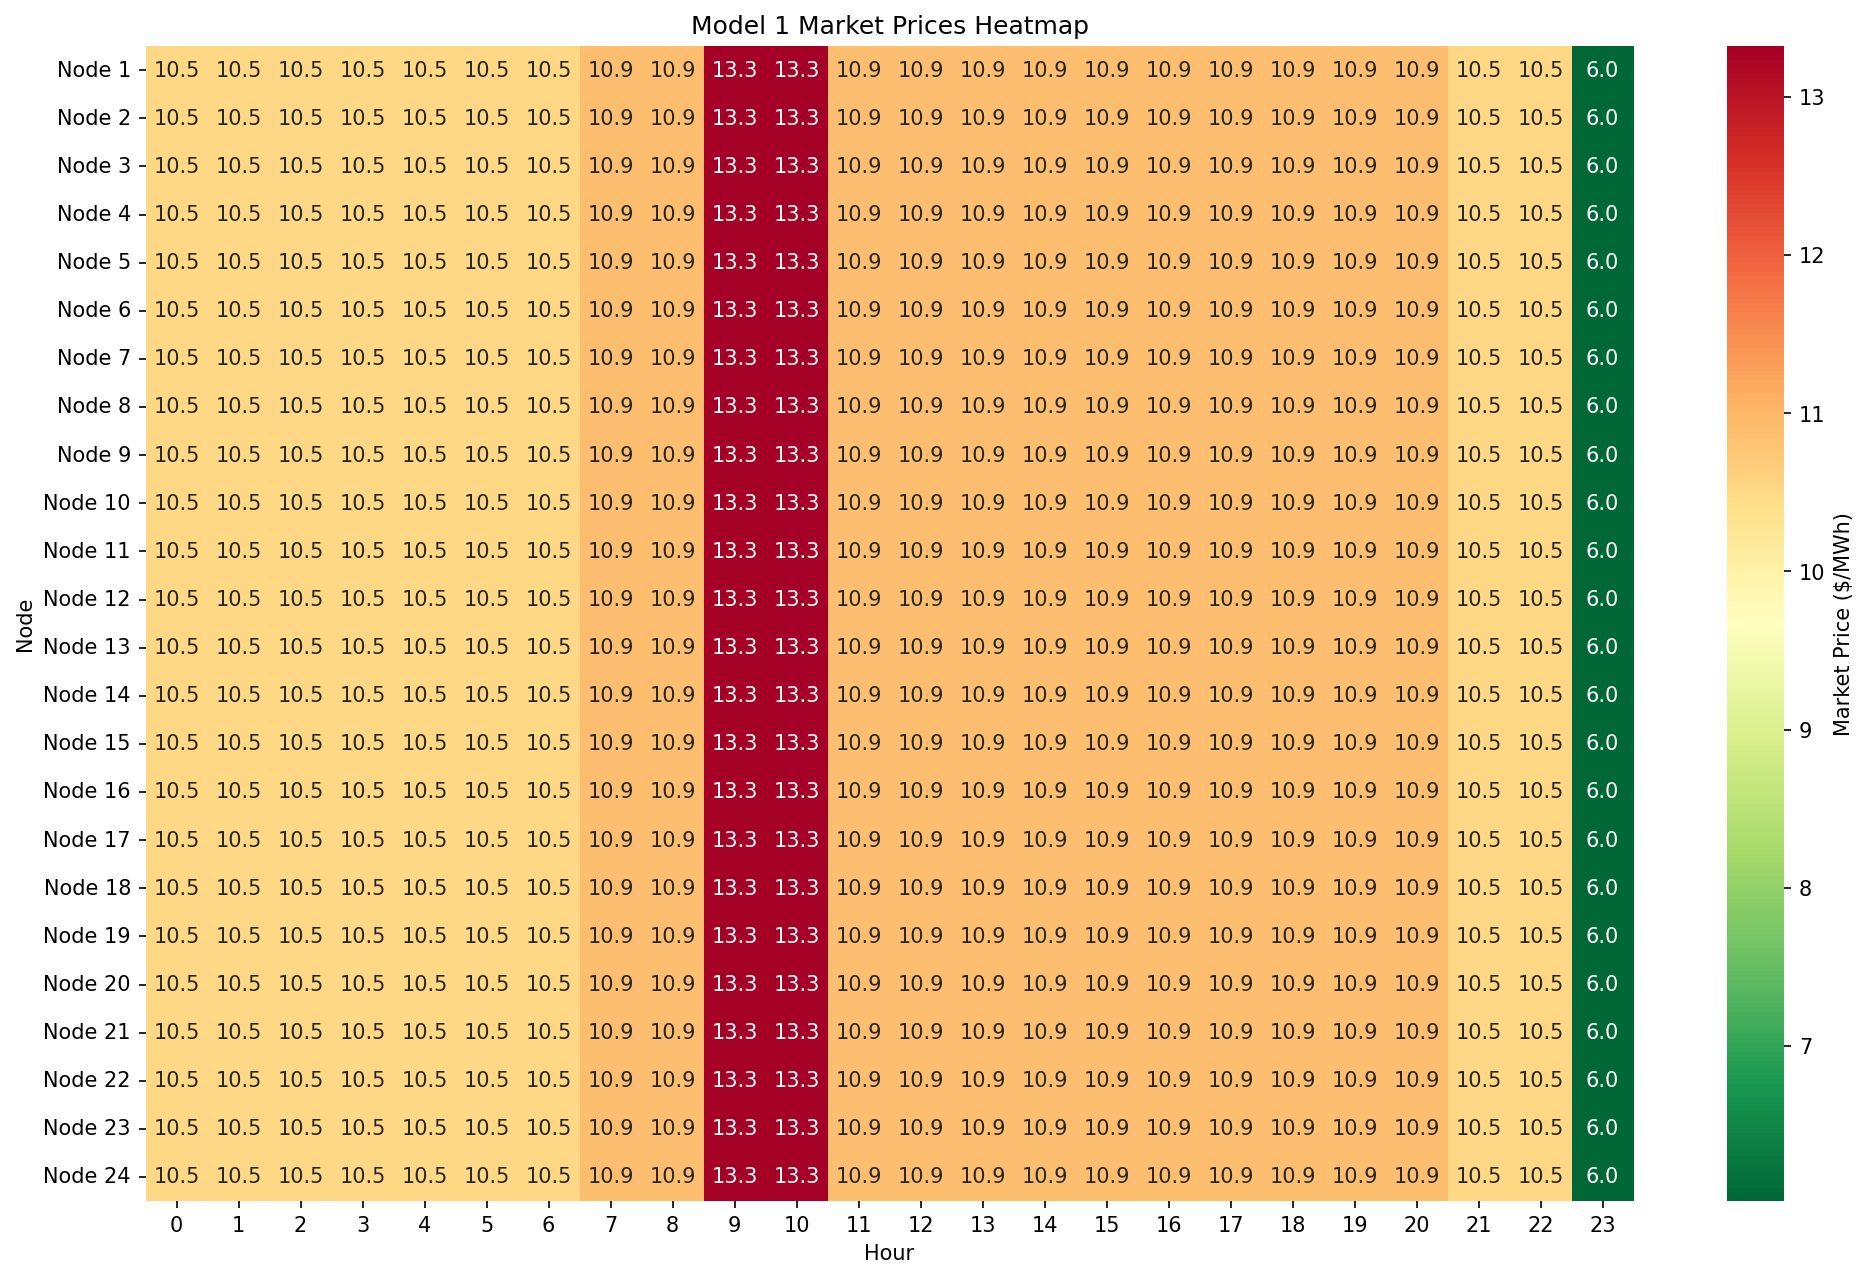

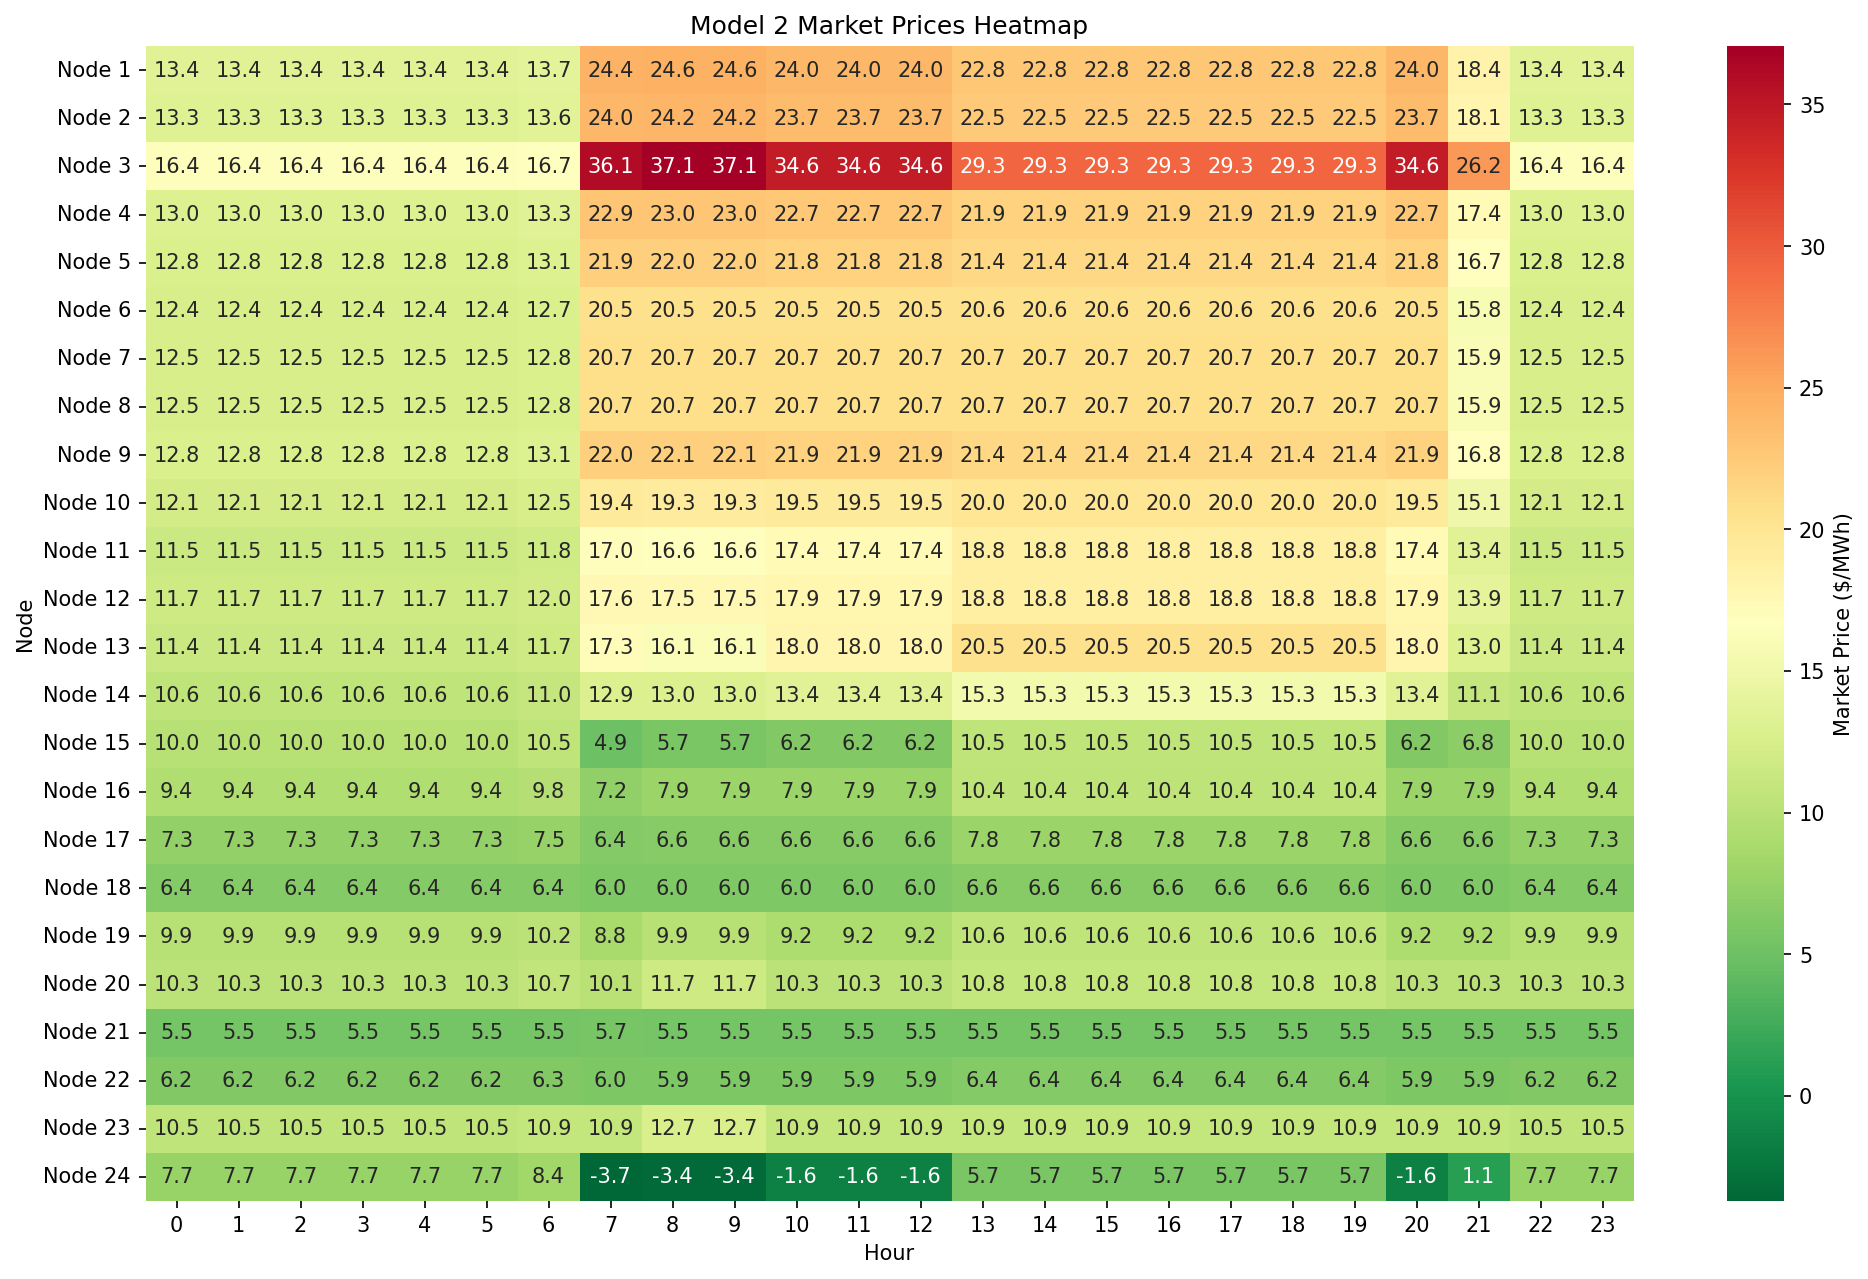

In [22]:
# Plot market prices for models 1 and 2 as a heatmap

def plot_market_prices(model, title):
    # market prices as a heatmap
    market_prices = {name.replace('balance_node_', 'Node '): constraint.dual.to_numpy() for name, constraint in model.constraints.items() if name.startswith('balance_node')}
    market_price_df = pd.DataFrame(market_prices)
    
    # plot heatmap
    plt.figure(figsize=(16, 10), dpi =150)
    sns.heatmap(market_price_df.T, annot=True, fmt='.1f', cmap='RdYlGn_r', cbar_kws={'label': 'Market Price ($/MWh)'})
    plt.title(f'{title} Market Prices Heatmap')
    plt.xlabel('Hour')
    plt.ylabel('Node')
    plt.show()

plot_market_prices(model1, 'Model 1')
plot_market_prices(model2, 'Model 2')

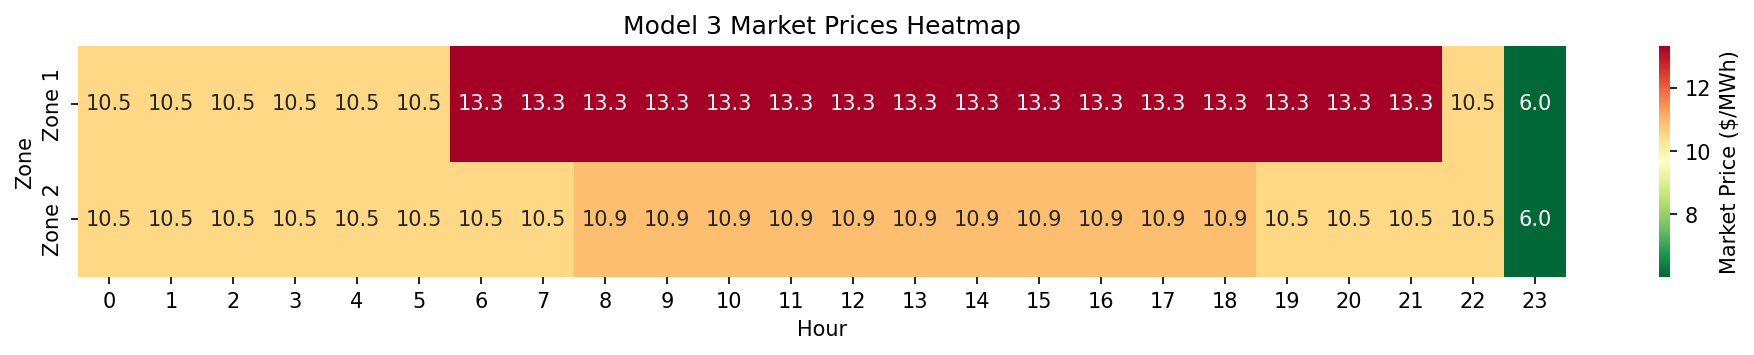

In [23]:
# plot heat map for model 3
def plot_market_prices_zones(model, title):
    # market prices for zones
    market_price_zone1 = model.constraints['balance_zone1'].dual.to_numpy()
    market_price_zone2 = model.constraints['balance_zone2'].dual.to_numpy()
    
    market_price_df = pd.DataFrame({
        'Zone 1': market_price_zone1,
        'Zone 2': market_price_zone2
    })

    # plot heatmap
    plt.figure(figsize=(16, 2), dpi=150)
    sns.heatmap(market_price_df.T, annot=True, fmt='.1f', cmap='RdYlGn_r', cbar_kws={'label': 'Market Price ($/MWh)'})
    plt.title(f'{title} Market Prices Heatmap')
    plt.xlabel('Hour')
    plt.ylabel('Zone')
    plt.show()

plot_market_prices_zones(model3, 'Model 3')

In model 1, there is no congestion, hence the market prices are uniform across all nodes. The total social welfare is the same that the copper plate case.

When modifying the network constraints, we can see that the system decouples and some nodes become more expensive, while others become cheaper. Notably, between 8 and 10 am, node 3 has a price of 37.1 \$/MWh, while node 24 has a negative price of -3.4 \$/MWh. This will be explored later in the analysis.

Finally when considering zonal prices, there is more coupling between the prices, but there is still a difference between 6 am and 9 pm. However, as we didn't model the internal lines, the solution will be unfeasible and corrections will be needed to make it feasible. Furthermore, the price observed per zone is the variable cost of the marginal generator in each zone.

#### Nodal prices explanations (model 2)

We will deepen on the analysis at 8 AM as it is the hour with the most significant price differences.

Congested lines will have a dual variable greater than zero associated to their capacity constraint. To find the congested lines we can look at those variables.

In [24]:
# find congested lines at 8 am in model 2
mu_line  = model2.constraints['line_capacity_pos'].dual + model2.constraints['line_capacity_neg'].dual
congested_lines = mu_line.sel(Hour=8).to_series()
congested_lines = congested_lines[congested_lines.abs() > 1e-9]
print("Congested lines in Model 2 at 8 AM:")
print(congested_lines)

Congested lines in Model 2 at 8 AM:
Line
7     55.059384
25     1.459654
Name: dual, dtype: float64


In [25]:
cl = congested_lines.reset_index()['Line'].unique()
lines_modified[lines_modified['Line'].isin(cl)]

,From,To,Line,Reactance_pu,Capacity_MVA
6,3,24,7,0.0840,133
24,15,21,25,0.0249,400


Both congestions occur in a similar area as node 24 is also connected to node 15. The vicinity of those nodes are:

- 21, 16, 15, 24, 3, 9, 1

We will examine those nodes in more detail, looking at the supply, demand and line flows.

In [26]:
# Get node data
def get_node_data(model,lines, node, hour):

    # Get Local marginal price at this node and hour
    market_price = float(model.constraints[f'balance_node_{node}'].dual.sel(Hour=hour))

    # Get the capacity, cost and actual generation of the generators at this node
    gen_data = []
    generators_at_node  = gen_constraints[gen_constraints['Node'] == node]
    for _, gen in generators_at_node.iterrows():
        unit = gen['Unit']
        capacity = gen['Pmax_MW']
        cost = gen['Ci_$/MWh']
        generation = float(model.variables['p_gen'].sel(Unit=unit, Hour=hour).solution)
        min_gen_dual = float(model.constraints[f'gen_pmin'].dual.sel(Unit=unit, Hour=hour))
        max_gen_dual = float(model.constraints[f'gen_pmax'].dual.sel(Unit=unit, Hour=hour))
        gen_data.append({'Unit': unit, 'Capacity_MW': capacity, 'Cost_$/MWh': cost, 'Generation_MW': generation, 'MinGenDual': min_gen_dual, 'MaxGenDual': max_gen_dual})
    
    # Get Wind generation at this node
    wind_data = []
    wind_farms_at_node = wind_forecast_generation[(wind_forecast_generation['Node'] == node) & (wind_forecast_generation['Hour'] == hour)]
    for _, wind in wind_farms_at_node.iterrows():
        unit = wind['Unit']
        forecast = wind['PForecast_MW']
        generation = float(model.variables['p_wind'].sel(Unit=unit, Hour=hour).solution)
        max_wind_dual = float(model.constraints[f'wind_pmax'].dual.sel(Unit=unit, Hour=hour))
        wind_data.append({'Unit': unit, 'Capacity_MW': forecast, 'Cost_$/MWh': 0, 'Generation_MW': generation, 'MaxWindDual': max_wind_dual})
    
    # get demand bids at this node and actual demand served
    demand_data = []
    demand_bids_at_node = demand_bid[(demand_bid['Node'] == node) & (demand_bid['Hour'] == hour)]
    for _, bid in demand_bids_at_node.iterrows():
        load = bid['Load']
        bid_id = bid['Bid']
        quantity = bid['Quantity_MW']
        price = bid['Price_$/MWh']
        demand_served = float(model.variables['p_demand'].sel(Load=load, Bid=bid_id, Hour=hour).solution)
        demand_dual = float(model.constraints[f'demand_limit'].dual.sel(Load=load, Bid=bid_id, Hour=hour))
        demand_data.append({'Load': load, 'Bid': bid_id, 'Quantity_MW': quantity, 'Price_$/MWh': price, 'Demand_Served_MW': demand_served, 'DemandDual': demand_dual})

    # Get flow data into the node
    line_data = []
    lines_connected= lines[(lines['To'] == node) | (lines['From'] == node)]
    for _, line in lines_connected.iterrows():
        line_id = int(line['Line'])
        capacity = float(line['Capacity_MVA'])
        flow = float(model.variables['p_line'].sel(Line=line_id, Hour=hour).solution)
        line_capacity_pos_dual = float(model.constraints[f'line_capacity_pos'].dual.sel(Line=line_id, Hour=hour))
        line_capacity_neg_dual = float(model.constraints[f'line_capacity_neg'].dual.sel(Line=line_id, Hour=hour))
        connection_node = line['From'] if line['To'] == node else line['To']
        if line['To'] == node:
            import_dual = line_capacity_pos_dual
            export_dual = line_capacity_neg_dual
            connection = 'from_' + str(int(connection_node)) if flow >= 0 else 'to_' + str(int(connection_node))
            price_at_node = float(model.constraints[f'balance_node_{int(connection_node)}'].dual.sel(Hour=hour))
        else:
            flow = - flow # reverse flow direction for lines where node is the "From"
            import_dual = line_capacity_neg_dual
            export_dual = line_capacity_pos_dual
            connection = 'from_' + str(int(connection_node)) if flow >= 0 else 'to_' + str(int(connection_node))
            price_at_node = float(model.constraints[f'balance_node_{int(connection_node)}'].dual.sel(Hour=hour))
        direction = 'Import' if flow >= 0 else 'Export'
        line_data.append({'Line': line_id, 
                          'Direction': direction, 
                          'Connection': connection,
                          'Flow_MW': flow, 
                          'Capacity_MW': capacity,
                          'line_capacity_pos_dual': line_capacity_pos_dual,
                          'line_capacity_neg_dual': line_capacity_neg_dual,
                          'MaxImportDual': import_dual, 
                          'MaxExportDual': export_dual,
                          'Price_at_connection_$/MWh': price_at_node})
        

    return {'Node': node, 
            'Hour': hour,
            'LMP_$/MWh': market_price,
            'Generators': gen_data, 
            'WindFarms': wind_data, 
            'DemandBids': demand_data, 
            'Lines': line_data}

In [27]:
def plot_node_data(node_data):
    node = node_data['Node']
    hour = node_data['Hour']
    market_price = node_data['LMP_$/MWh']
    gen_data = node_data['Generators']
    wind_data = node_data['WindFarms']
    demand_data = node_data['DemandBids']
    line_data = node_data['Lines']

    plt.figure(figsize=(10, 4), dpi=300)
    ax = plt.gca()

    used_labels = set()
    max_text_y = 0.0

    def bar_with_nominal_label(x, nominal, actual, nominal_color, actual_color, nominal_legend, actual_legend, price_text=""):
        nonlocal max_text_y

        l1 = nominal_legend if nominal_legend not in used_labels else ""
        l2 = actual_legend if actual_legend not in used_labels else ""
        ax.bar(x, nominal, color=nominal_color, edgecolor='black', label=l1)
        ax.bar(x, actual, color=actual_color, edgecolor='black', label=l2)
        used_labels.update([nominal_legend, actual_legend])

        # Label for nominal capacity
        nominal_label_y = nominal + max(1, 0.01 * abs(nominal))
        label_text = f"{nominal:.1f}"
        if price_text:
            label_text += f"\n({price_text} $/MWh)"

        ax.text(
            x, nominal_label_y,
            label_text,
            ha='center', va='bottom', fontsize=10, rotation=0
        )
        max_text_y = max(max_text_y, nominal_label_y)

        # Label for actual if different from nominal
        if abs(actual - nominal) > 0.01:
            actual_label_y = actual + max(1, 0.01 * abs(actual))
            ax.text(
                x, actual_label_y,
                f"{actual:.1f}",
                ha='center', va='bottom', fontsize=10, rotation=0, color='darkred', weight='bold'
            )
            max_text_y = max(max_text_y, actual_label_y)

    # Generators
    for gen in gen_data:
        label = gen['Unit']
        bar_with_nominal_label(
            x=label,
            nominal=gen['Capacity_MW'],
            actual=gen['Generation_MW'],
            nominal_color='lightgrey',
            actual_color='blue',
            nominal_legend='Gen Capacity',
            actual_legend='Gen Output',
            price_text=f"{gen['Cost_$/MWh']:.1f}"
        )

    # Wind
    for wind in wind_data:
        label = wind['Unit']
        bar_with_nominal_label(
            x=label,
            nominal=wind['Capacity_MW'],
            actual=wind['Generation_MW'],
            nominal_color='lightgrey',
            actual_color='cyan',
            nominal_legend='Wind Capacity',
            actual_legend='Wind Output',
            price_text=f"{wind['Cost_$/MWh']:.1f}"
        )

    # Demand bids
    for demand in demand_data:
        label = f"{demand['Load']}_{demand['Bid']}"
        bar_with_nominal_label(
            x=label,
            nominal=demand['Quantity_MW'],
            actual=demand['Demand_Served_MW'],
            nominal_color='lightgrey',
            actual_color='orange',
            nominal_legend='Demand Bid Quantity',
            actual_legend='Demand Served',
            price_text=f"{demand['Price_$/MWh']:.1f}"
        )

    # Lines
    for line in line_data:
        label = line['Connection']
        bar_with_nominal_label(
            x=label,
            nominal=line['Capacity_MW'],
            actual=abs(line['Flow_MW']),
            nominal_color='lightgrey',
            actual_color='green' if line['Direction'] == 'Import' else 'red',
            nominal_legend='Line Capacity',
            actual_legend='Line Flow',
            price_text=f"{line['Price_at_connection_$/MWh']:.1f}"
        )

    # Add top margin so labels don't overlap title
    if max_text_y > 0:
        ax.set_ylim(top=max_text_y * 1.20)

    plt.xticks(rotation=0)
    plt.ylabel('MW')
    plt.title(f'Node {node} - Hour {hour} - LMP: {market_price:.2f} $/MWh')
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.grid(alpha=0.3)
    sns.despine()
    plt.show()

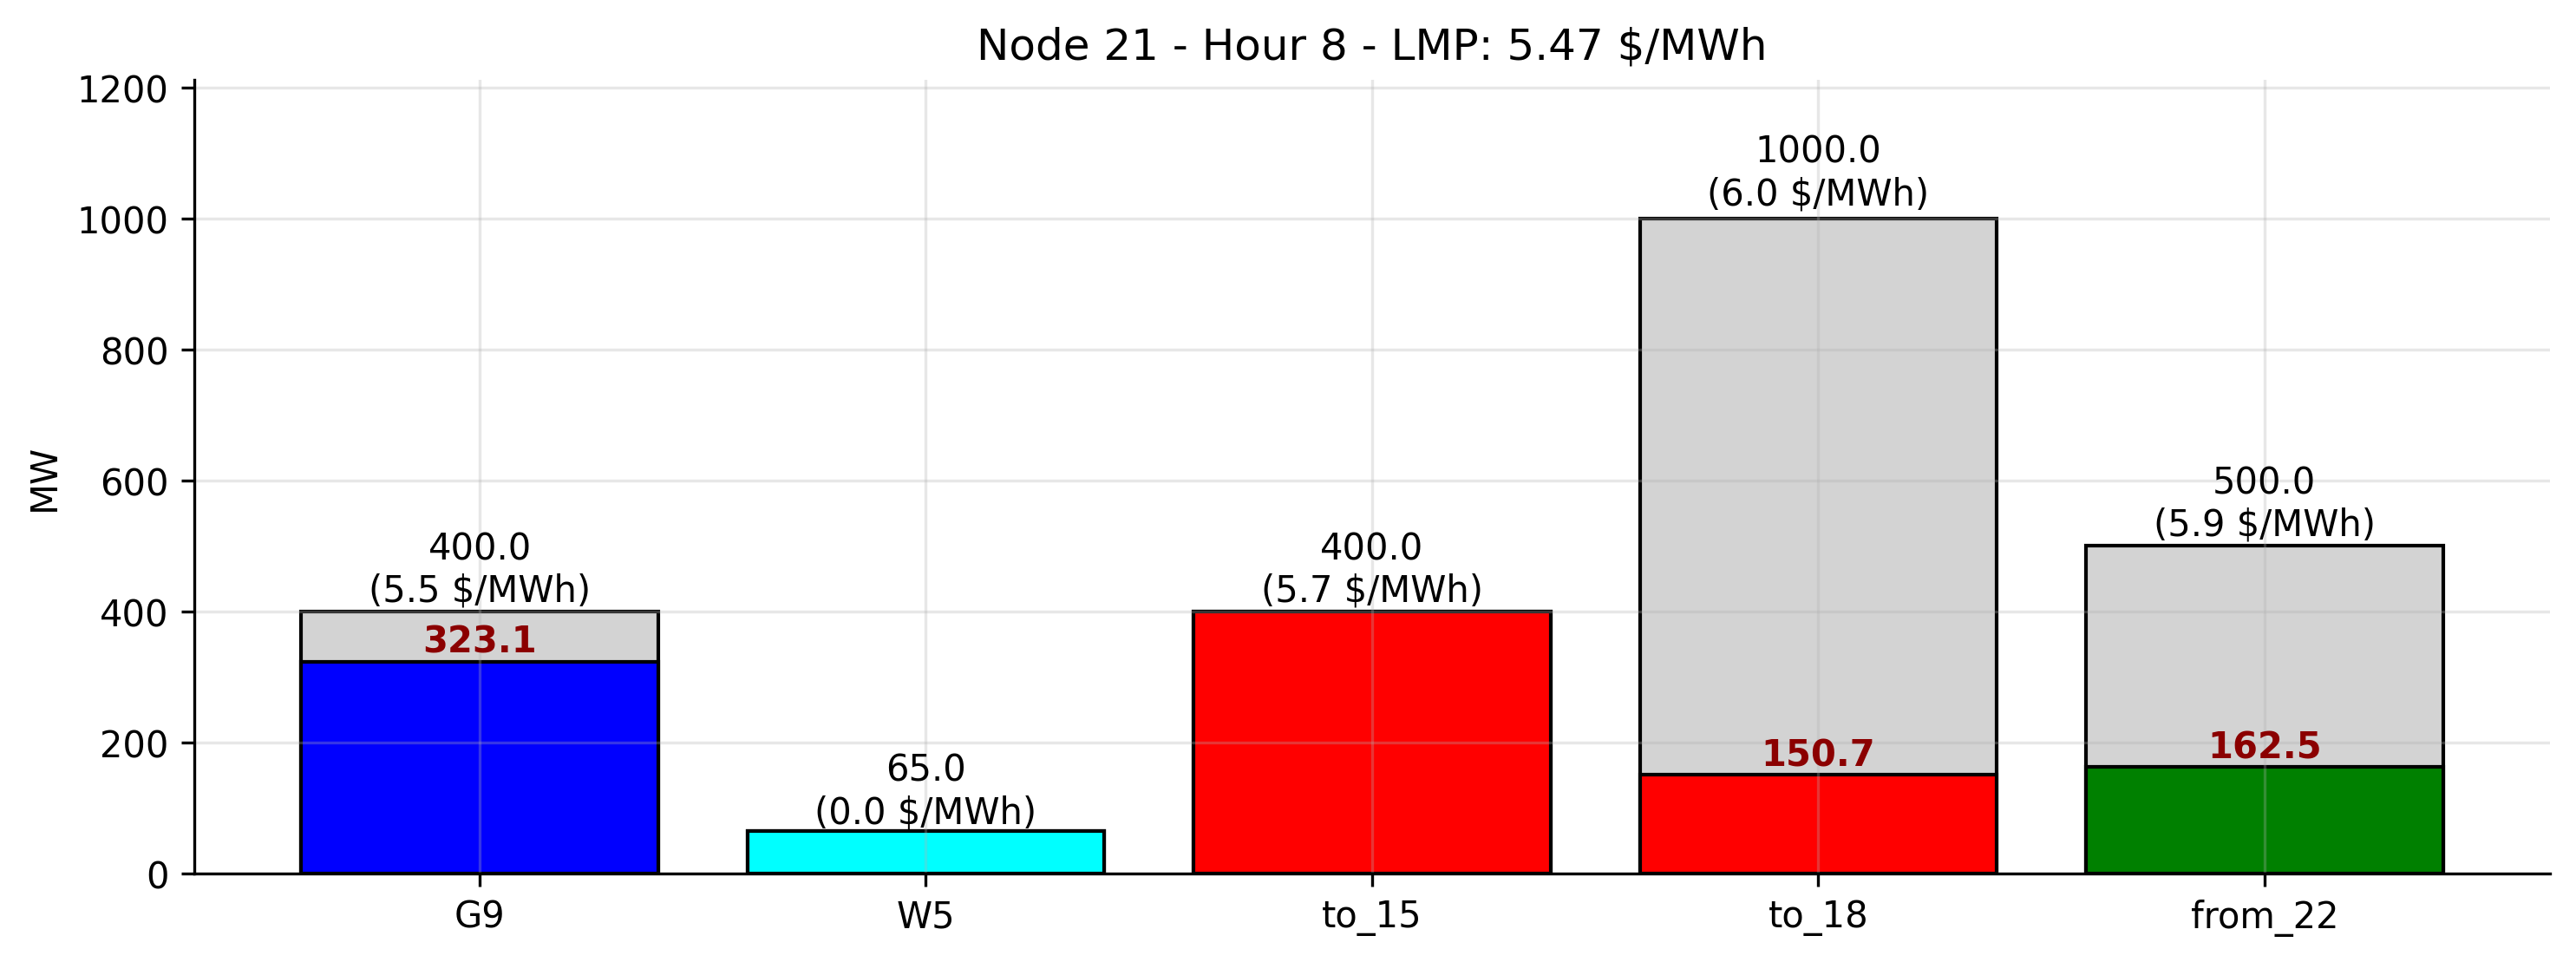

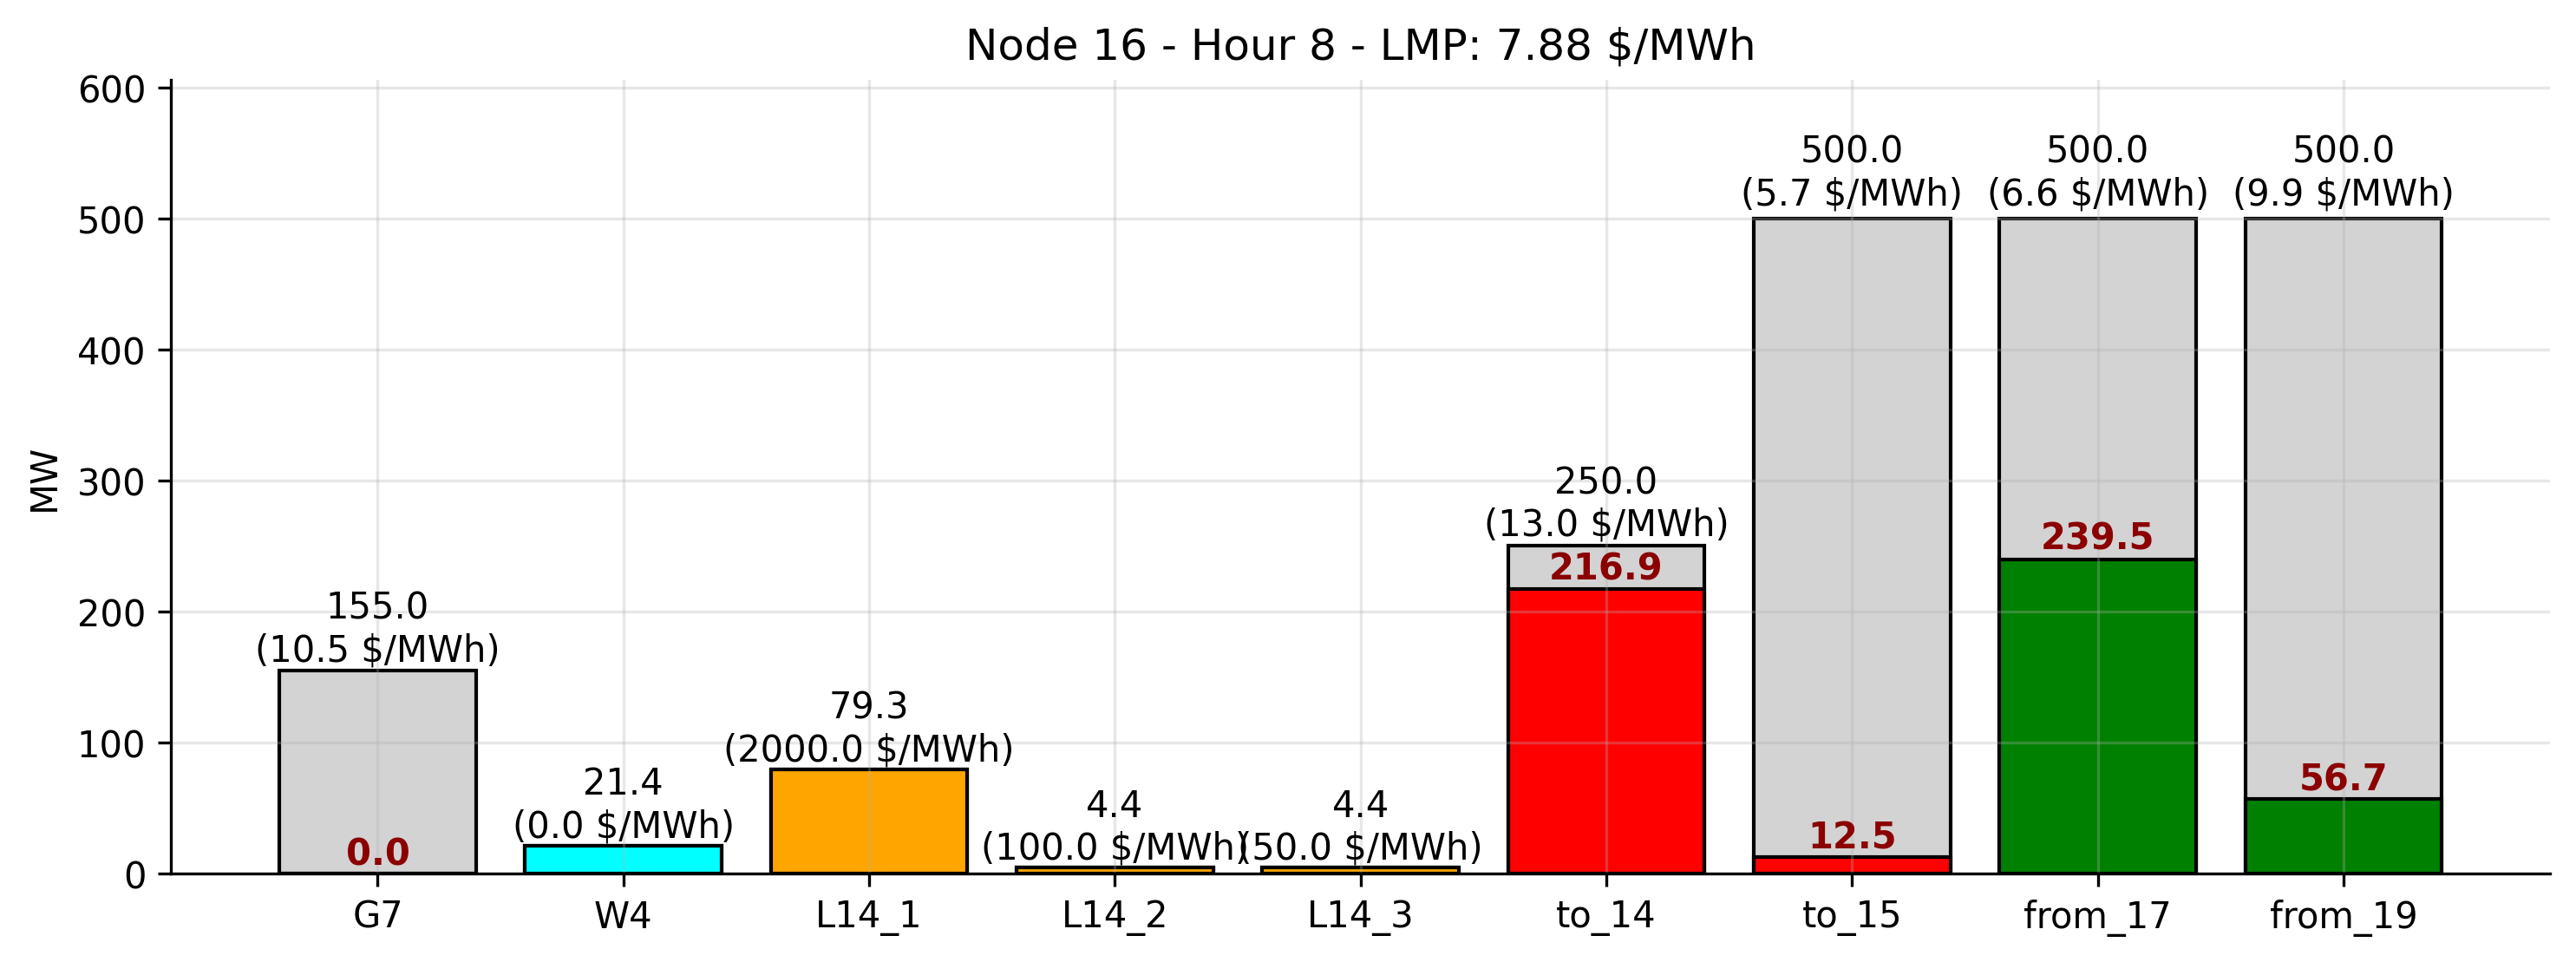

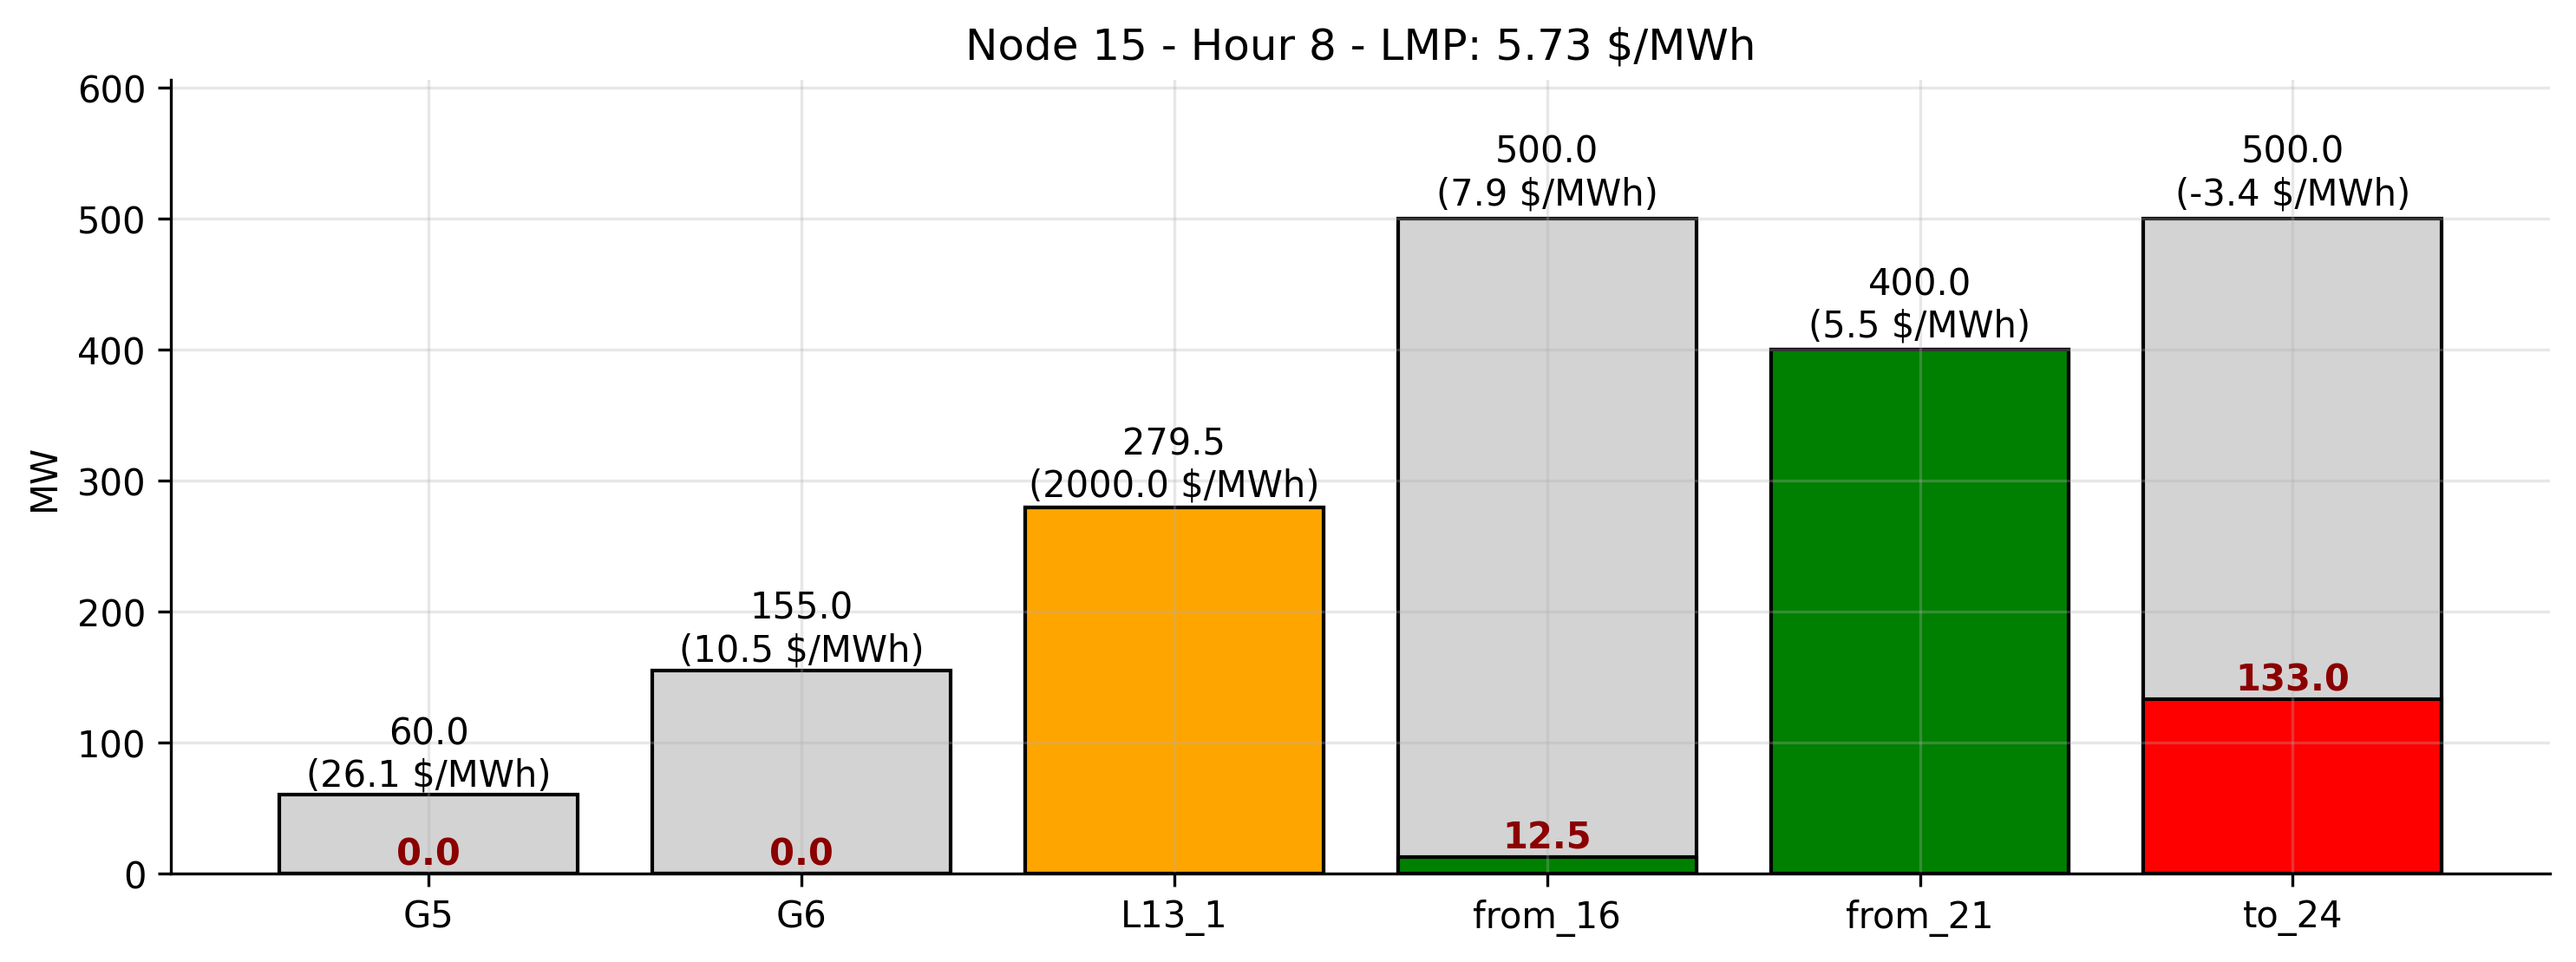

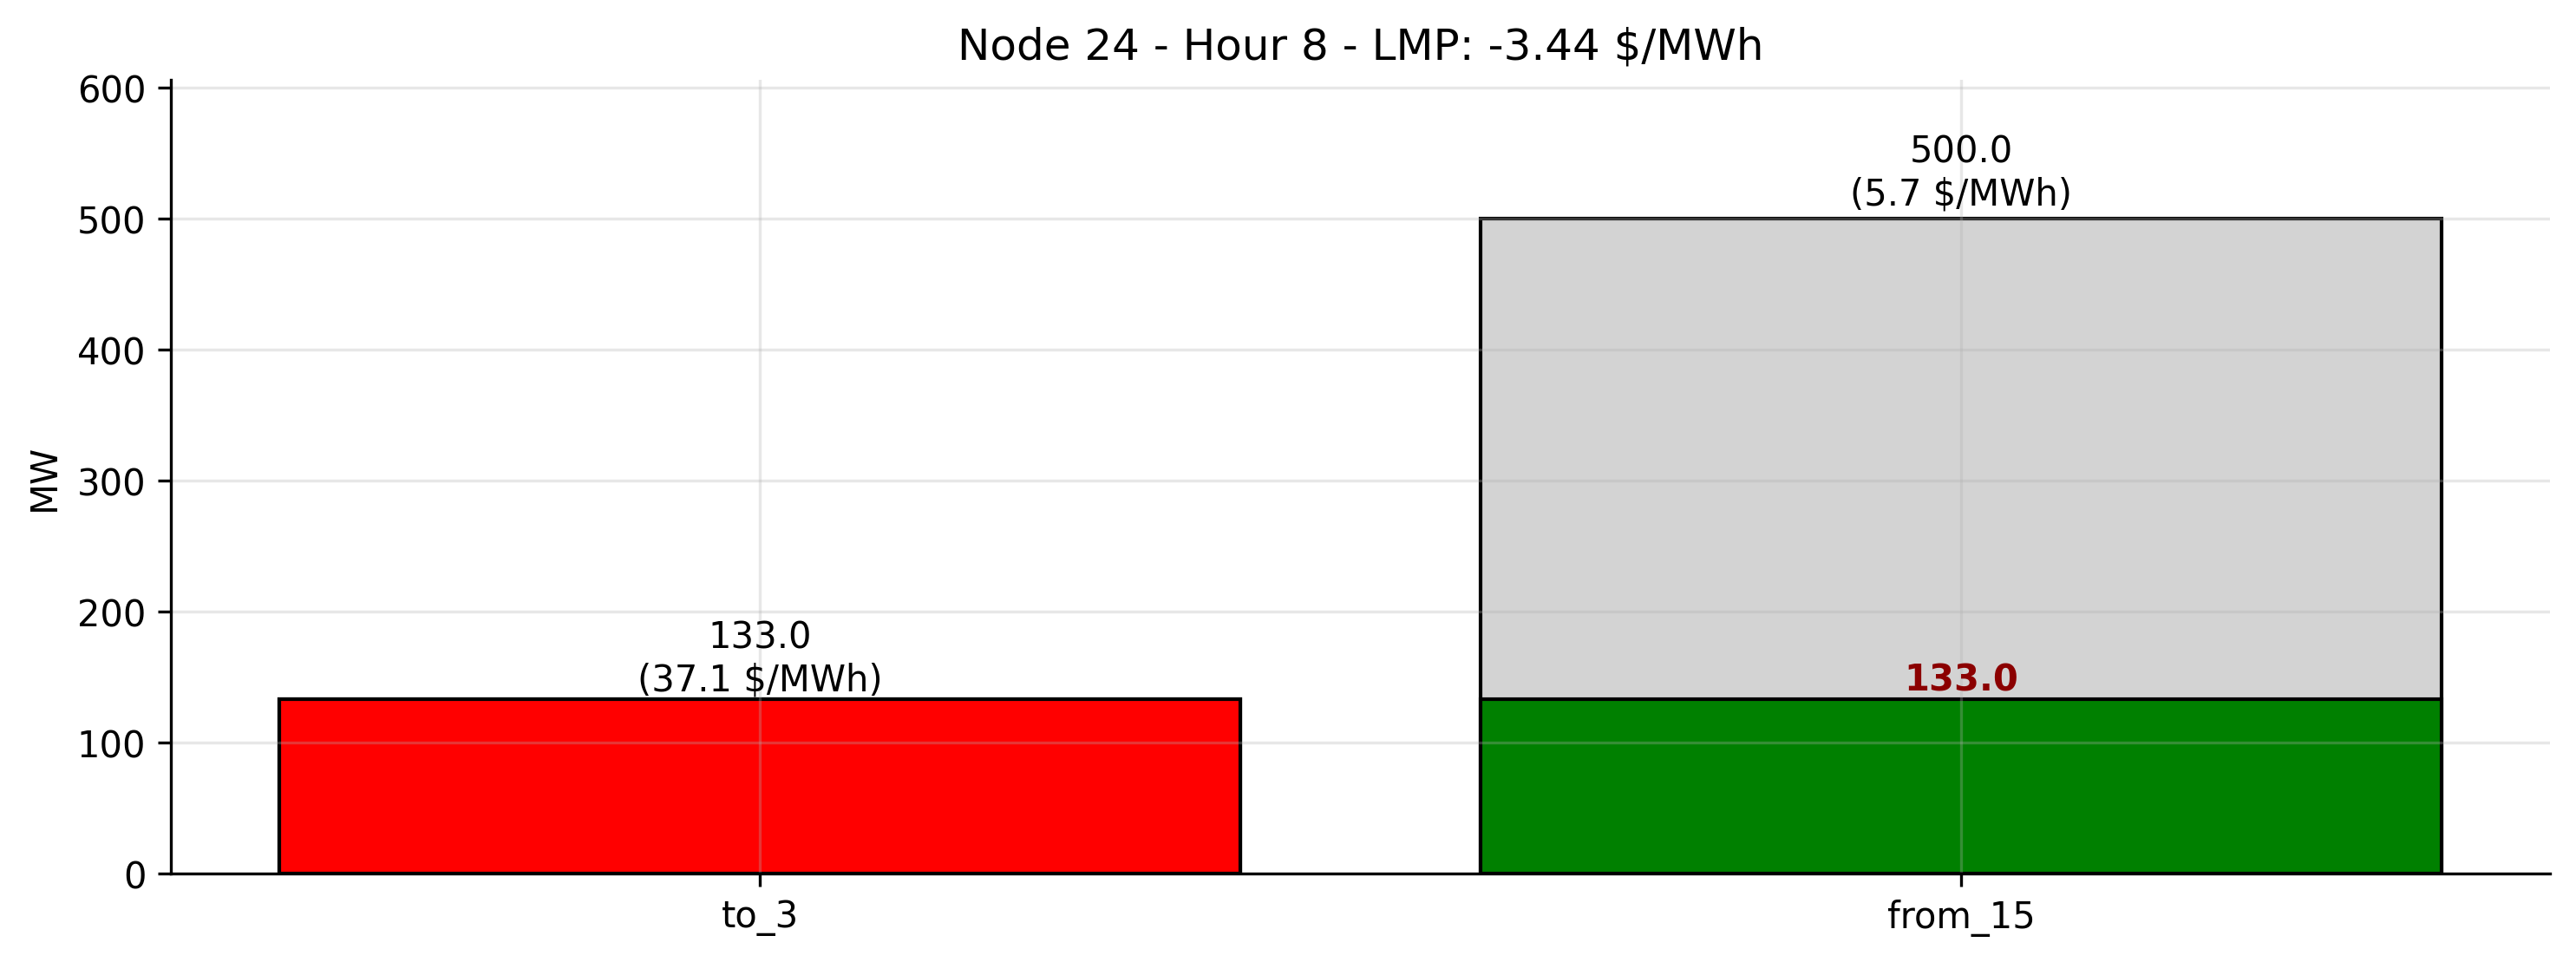

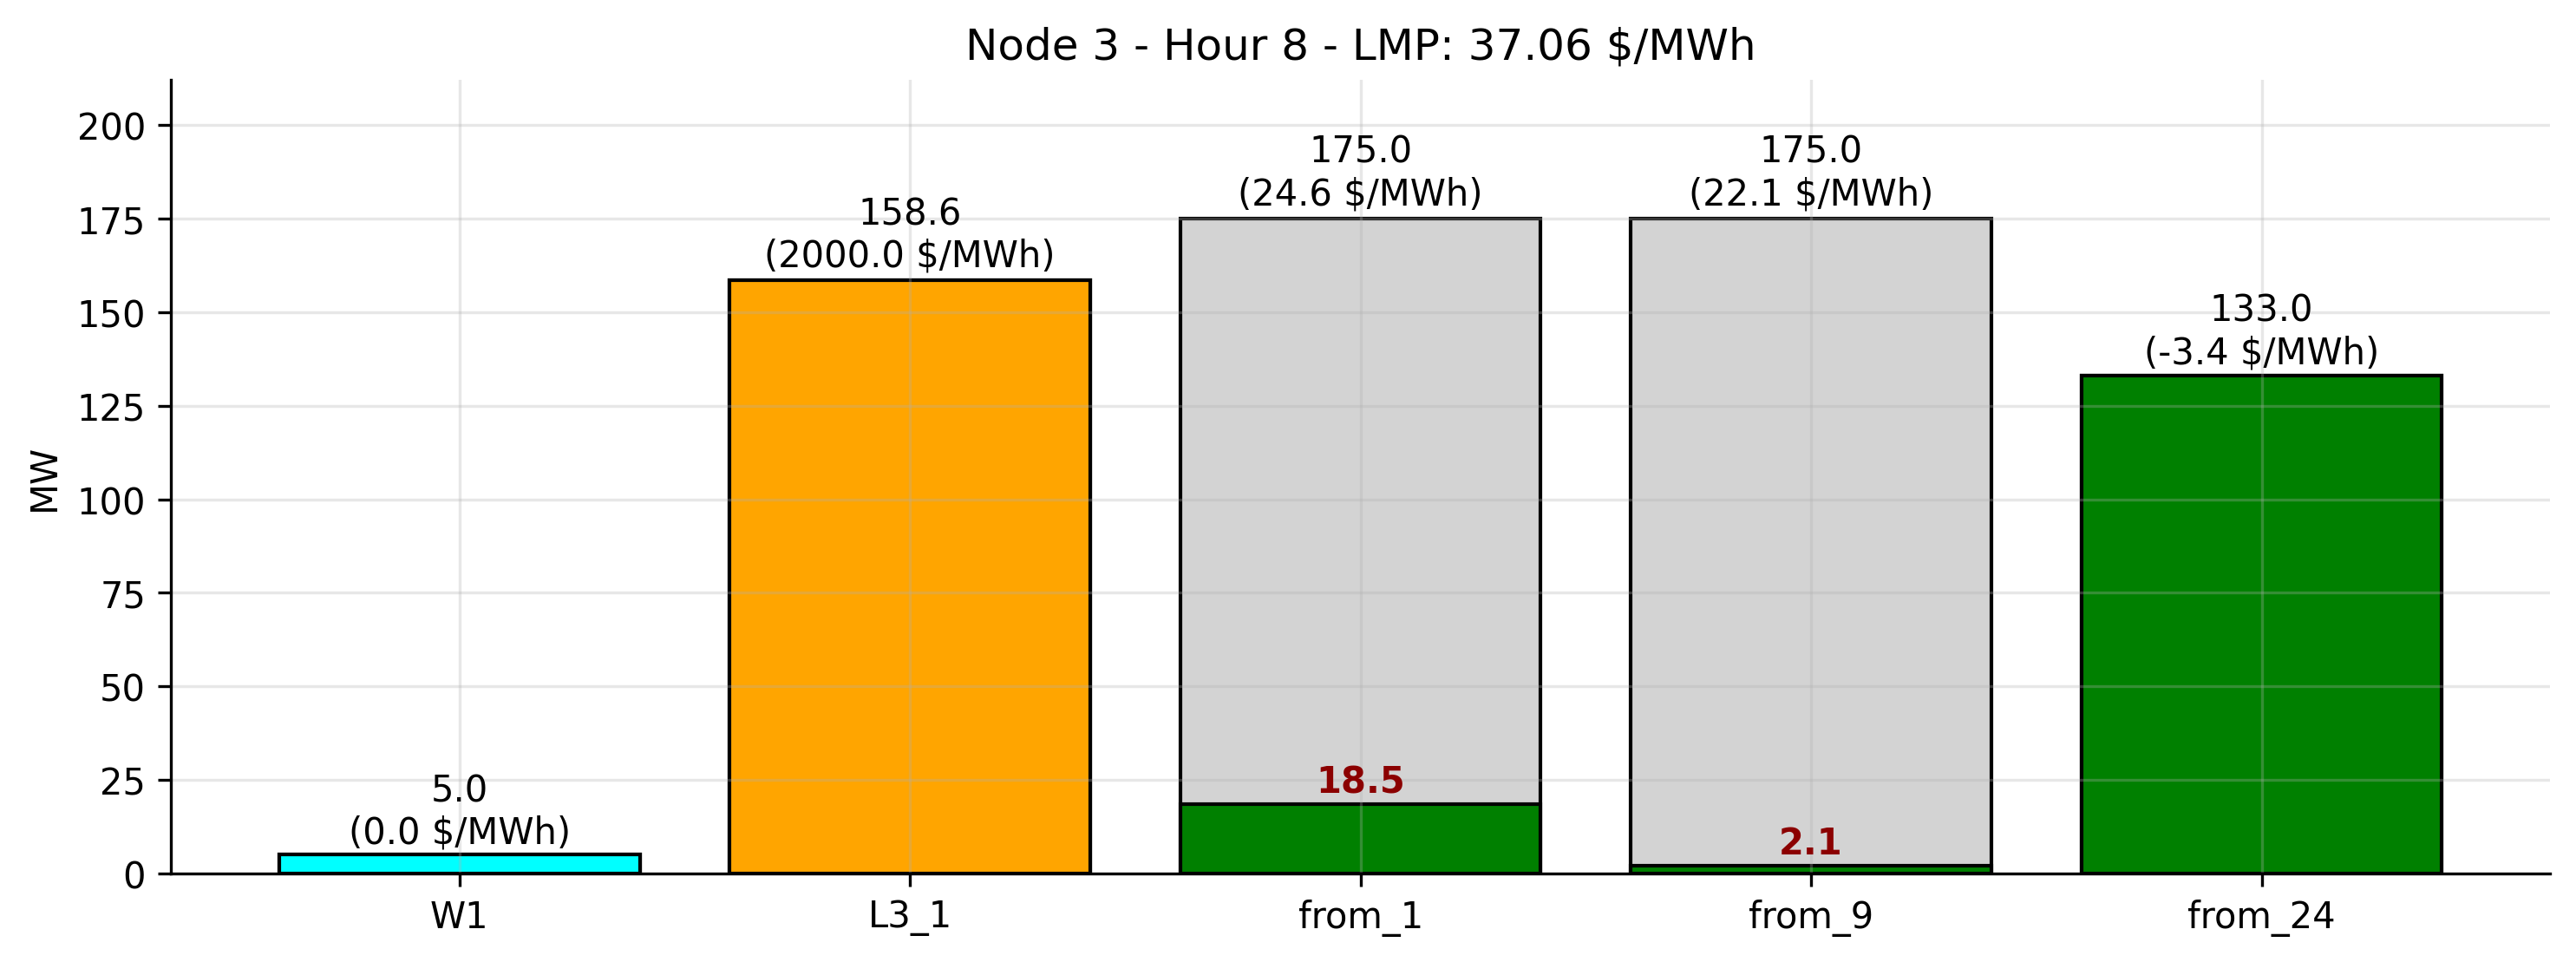

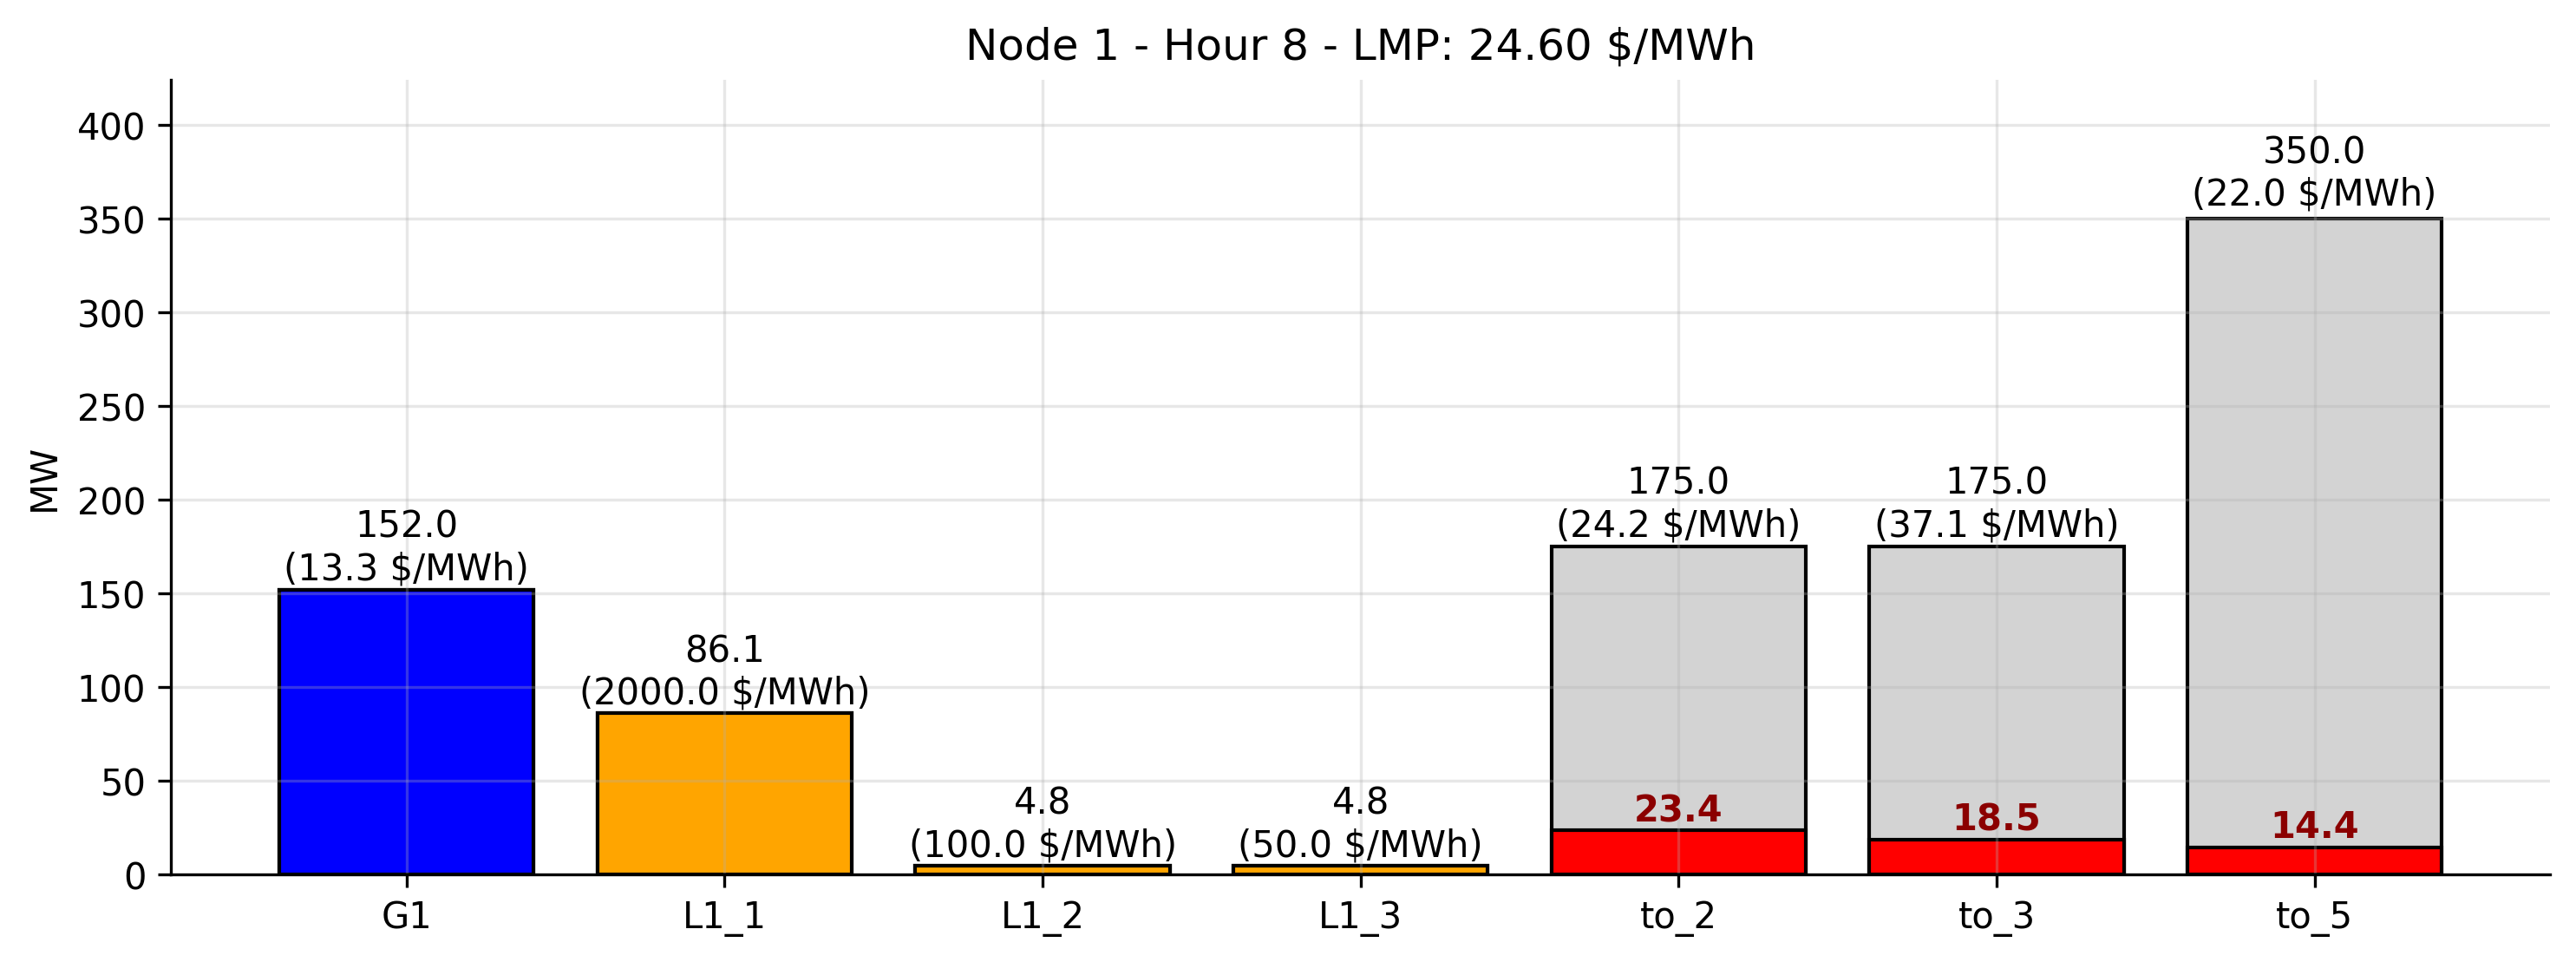

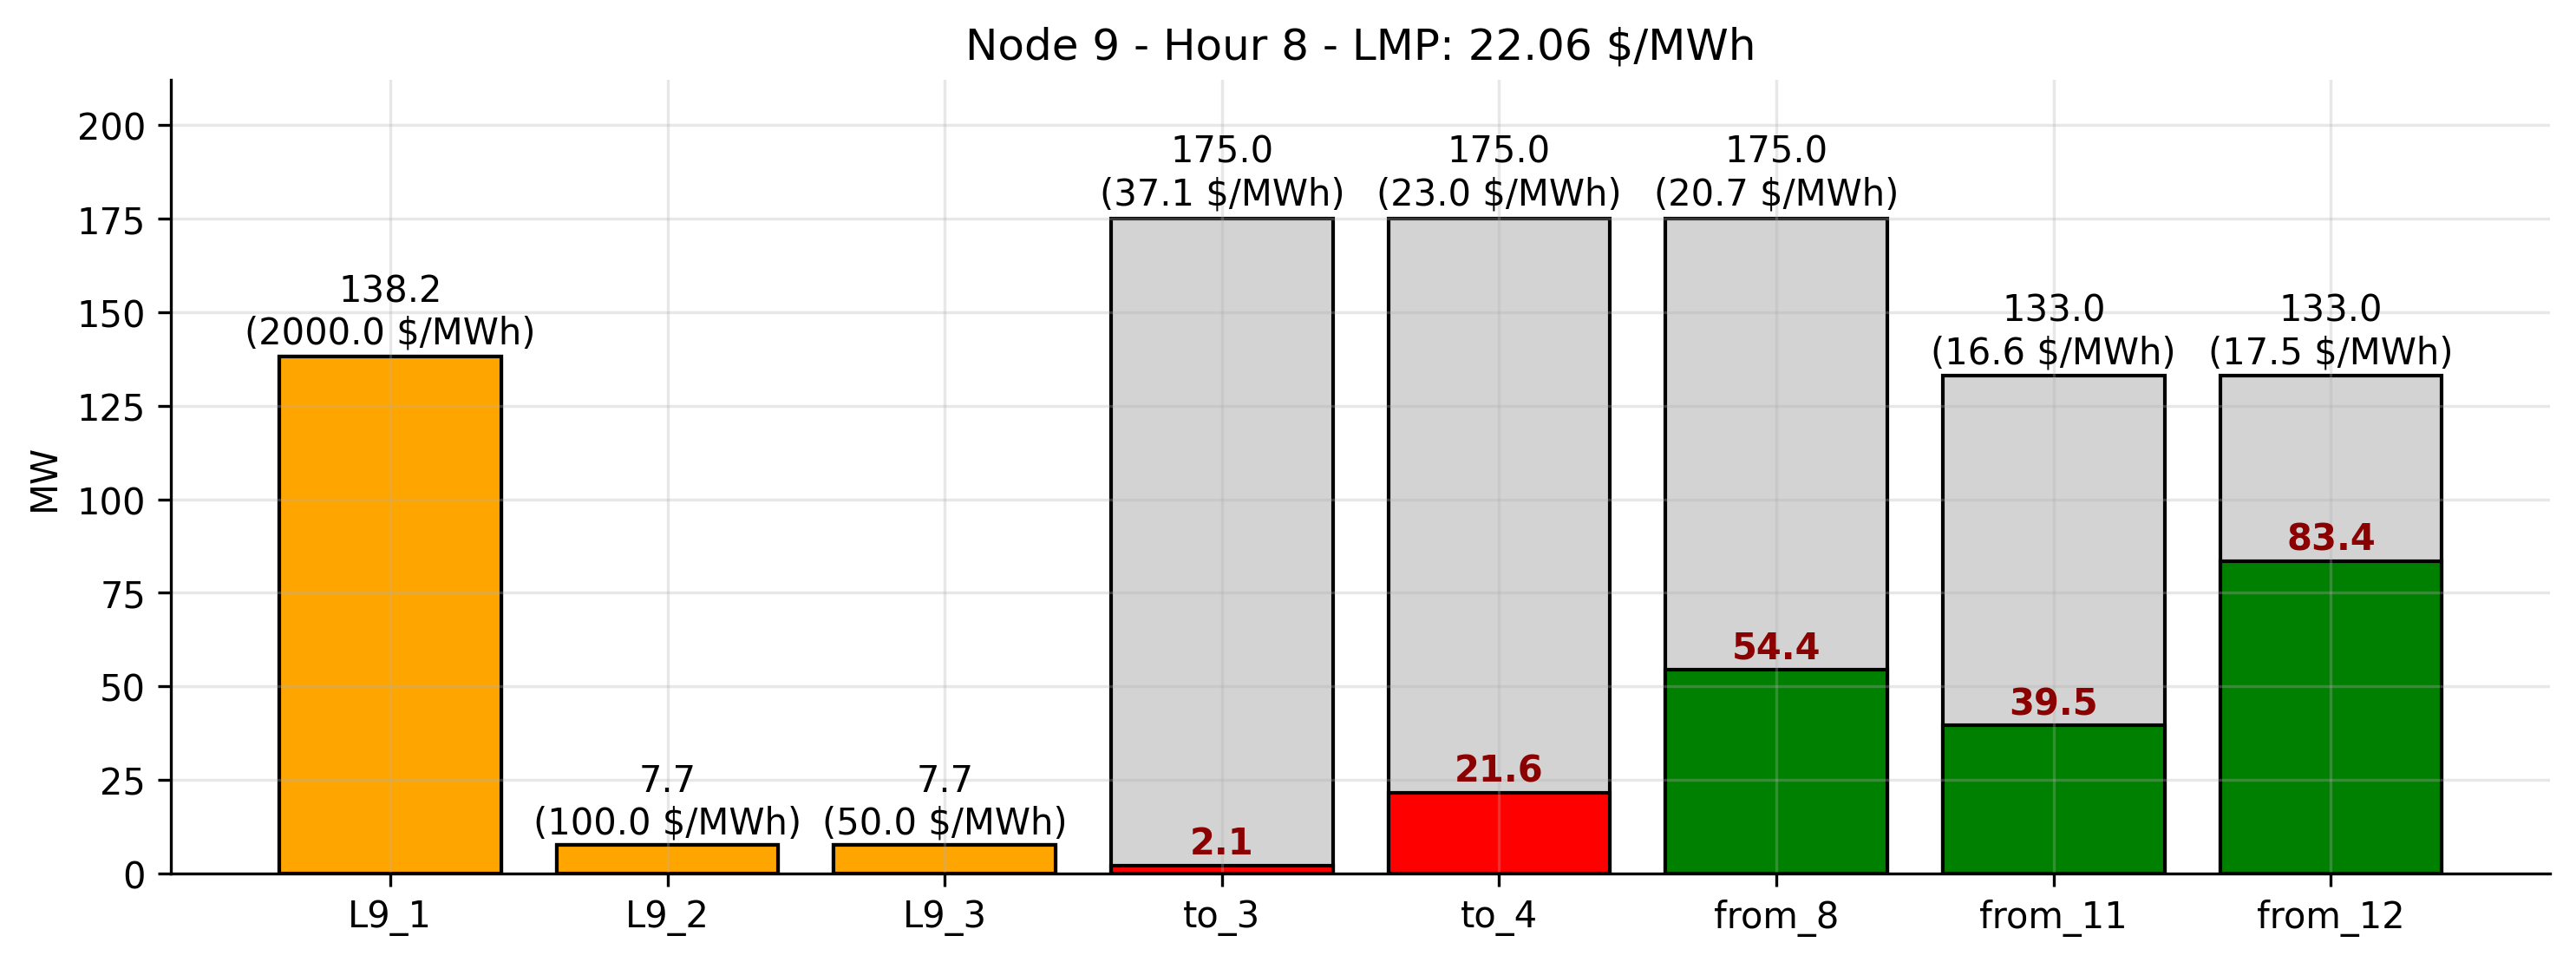

In [28]:
# model 2
for node in [21, 16, 15,24,3,1,9]:
    node_data_m2 = get_node_data(model2, lines_modified, node=node, hour=8)
    plot_node_data(node_data_m2)

The congestion at node 15 is not too bad, as there are two generators (one with cost of 10.5 \$/MWh) that could be generating, but it's cheaper to import from node 21; that's why that line is maxed out. However the biggest congestion is at node 3, where it can't import cheap energy from zone 2 due to the limitation of the line connecting it to node 24. At 8 AM the local wind generation at node 3 is very low while the demand is high, hence it needs to import as much as possible from the cheapest generation (node 24).

**But why is the price at node 3 so high even if it has a lot of capacity to import from nodes 1 and 9 whose prices are not that high?**

This is because of the characteristics of the DC-OPF, where the angle restrictions make that every line and node are interdependent. Hence, the congestion in the line connecting node 3 to node 24 affects the flows and prices in the rest of the system, and the price reflects the cost of that congestion in all the system.

That's why we can see counterintuitive flows, for example in node 1, where it's exporting to nodes 2 and 5 even when its price is higher than theirs.  

**Now, how can we explain the prices?**

The prices can be decomposed into the system marginal cost and the congestion cost. The first one is the same across all nodes and it's equivalent to the lmp at the slack bus. Then the congestion at each node is the sum of the dual variables of the congested lines multiplied by the influence of those lines in the node. The influence comes from the connections and the reactances of the lines. We call it PTDF (Power Transfer Distribution Factor).

PTDF has the shape of (number of lines, number of nodes) and it represents how much the flow in each line changes when injecting 1 MW in a node and withdrawing it in the slack bus. 

The formula is:

 - LMP_node = lambda_sys + sum_over_lines(PTDF_line_node * dual_line_capacity)

 Where:
 - dual_line_capacity = dual_line_max + dual_line_min (one will be zero)

In [29]:
# Functions to compute ptdf and decompose lmp into components

def compute_ptdf(lines, slack_bus=None):
    """
    Compute PTDF matrix for a DC power flow network.

    Parameters
    ----------
    lines : pd.DataFrame
        Must contain columns ['From','To','Reactance_pu']
    slack_bus : int, optional
        Slack bus index. If None, the first bus is used.

    Returns
    -------
    PTDF : pd.DataFrame
        PTDF matrix (lines x buses)
    """

    # Buses
    buses = np.sort(pd.unique(lines[['From', 'To']].values.ravel()))
    n_bus = len(buses)
    n_line = len(lines)

    bus_index = {b: i for i, b in enumerate(buses)}

    if slack_bus is None:
        slack_bus = buses[0]

    slack_i = bus_index[slack_bus]

    # Build Bbus
    Bbus = np.zeros((n_bus, n_bus))

    for _, row in lines.iterrows():
        i = bus_index[row['From']]
        j = bus_index[row['To']]
        bij = 1 / row['Reactance_pu']

        Bbus[i, i] += bij
        Bbus[j, j] += bij
        Bbus[i, j] -= bij
        Bbus[j, i] -= bij

    # Remove slack bus row and column
    Bbus_red = np.delete(np.delete(Bbus, slack_i, axis=0), slack_i, axis=1)

    # Check connectivity
    if np.linalg.matrix_rank(Bbus_red) < Bbus_red.shape[0]:
        raise ValueError("Network is not fully connected — Bbus is singular.")

    # Build Bf using positional indexing (fix: use enumerate to avoid DataFrame index issues)
    Bf = np.zeros((n_line, n_bus))

    for k, (_, row) in enumerate(lines.iterrows()):
        i = bus_index[row['From']]
        j = bus_index[row['To']]
        bij = 1 / row['Reactance_pu']

        Bf[k, i] = bij
        Bf[k, j] = -bij

    # Remove slack column
    Bf_red = np.delete(Bf, slack_i, axis=1)

    # PTDF = Bf_red @ Bbus_red^-1  (using solve for better numerical stability)
    PTDF_red = np.linalg.solve(Bbus_red.T, Bf_red.T).T

    # Reinsert slack column (zeros)
    PTDF = np.zeros((n_line, n_bus))
    cols = list(range(n_bus))
    cols.remove(slack_i)
    PTDF[:, cols] = PTDF_red

    return pd.DataFrame(PTDF, columns=buses, index=lines['Line'])

def decompose_lmp(model, ptdf, lines, slack_bus, node, hour):
    lmp_node   = float(model.constraints[f'balance_node_{node}'].dual.sel(Hour=hour))
    lambda_sys = float(model.constraints[f'balance_node_{slack_bus}'].dual.sel(Hour=hour))

    # Congestion component: sum over congested lines of (PTDF * line_shadow_price)
    congestion = 0
    for _, line in lines.iterrows():
        line_id = int(line['Line'])
        mu_pos = float(model.constraints['line_capacity_pos'].dual.sel(Line=line_id, Hour=hour))
        mu_neg = float(model.constraints['line_capacity_neg'].dual.sel(Line=line_id, Hour=hour))
        mu_line = mu_pos + mu_neg  # one of these will be zero
        congestion += ptdf.loc[line_id, node] * mu_line


    return {
        'LMP':        lmp_node,
        'Lambda':     lambda_sys,
        'Congestion': float(congestion),
        'Check':      round(lmp_node - lambda_sys - congestion, 6)  # should be ~0
    }



Here we can calculate the PTDF and decompose the LMP at different nodes to explain the price. We can also compare it to the case of model 1, where the system price is the same across all nodes, hence the congestion cost is zero for all. 

In [30]:
ptdf = compute_ptdf(lines_modified, 13)
decompose_lmp(model2, ptdf, lines_modified, slack_bus=13, node=12, hour=8)

{'LMP': 17.47974240114935,
 'Lambda': 16.113680010465966,
 'Congestion': 1.366062390683368,
 'Check': np.float64(0.0)}

In [31]:
ptdf_model1 = compute_ptdf(lines, 13)
decompose_lmp(model1, ptdf_model1, lines, slack_bus=13, node=12, hour=8)

{'LMP': 10.890000000000004,
 'Lambda': 10.89,
 'Congestion': 0.0,
 'Check': np.float64(0.0)}

Lastly we can calculate the profits of the generators, the payments to consumers and congestion rents, and see how they differ between the models.

In [32]:
def calculate_payments(model, lines):
    generators = {}
    utility_for_generators = {}
    demands = {}
    utility_for_loads = {}
    crent = {}
    for node in range(1, 25):
        for hour in range(24):
            node_data = get_node_data(model, lines, node=node, hour=hour)
            lmp = node_data['LMP_$/MWh']

            # Payments to generators
            for gen in node_data['Generators']:
                payment = gen['Generation_MW'] * lmp
                utility = gen['Generation_MW'] * (lmp - gen['Cost_$/MWh'])
                generators[gen['Unit']] = generators.get(gen['Unit'], 0) + payment
                utility_for_generators[gen['Unit']] = utility_for_generators.get(gen['Unit'], 0) + utility

            # Payments to wind farms
            for wind in node_data['WindFarms']:
                payment = wind['Generation_MW'] * lmp
                utility = wind['Generation_MW'] * (lmp - wind['Cost_$/MWh'])
                generators[wind['Unit']] = generators.get(wind['Unit'], 0) + payment
                utility_for_generators[wind['Unit']] = utility_for_generators.get(wind['Unit'], 0) + utility

            # Payments from loads
            for demand in node_data['DemandBids']:
                payment = demand['Demand_Served_MW'] * lmp
                utility = demand['Demand_Served_MW'] * (demand['Price_$/MWh'] - lmp)
                demands[(demand['Load'], demand['Bid'])] = demands.get((demand['Load'], demand['Bid']), 0) + payment
                utility_for_loads[(demand['Load'], demand['Bid'])] = utility_for_loads.get((demand['Load'], demand['Bid']), 0) + utility

            # Congestion rents from lines
            for line in node_data['Lines']:
                payment = line['Flow_MW'] * (lmp - line['Price_at_connection_$/MWh'])
                crent[line['Line']] = crent.get(line['Line'], 0) + payment/2

    return generators, demands, crent, utility_for_generators, utility_for_loads

In [33]:
results = {}
for i, (model, lines) in enumerate([(model1, lines), (model2, lines_modified)], start=1):

    generator_payments, demands_payments, crent, utility_for_generators, utility_for_loads = calculate_payments(model, lines)
    results[f'Model {i}'] = {
        'generator_payments': generator_payments,
        'demands_payments': demands_payments,
        'congestion_rents': crent,
        'utility_for_generators': utility_for_generators,
        'utility_for_loads': utility_for_loads
    }
    total_payments_to_generators = sum(generator_payments.values())
    total_payments_from_loads = sum(demands_payments.values())
    total_congestion_rents = sum(crent.values())
    total_utility_generators = sum(utility_for_generators.values())
    total_utility_loads = sum(utility_for_loads.values())

    print(f"\n{'='*5} Payments Summary for Model {i} {'='*5}\n")
    print(f"Total payments to generators: {total_payments_to_generators:,.2f} $")
    print(f"Total payments from loads: {total_payments_from_loads:,.2f} $")
    print(f"Total congestion rents: {total_congestion_rents:,.2f} $\n")
    print(f"Net payments (should be zero): {(total_payments_to_generators - total_payments_from_loads + total_congestion_rents):,.2f} $\n")
    print(f"Total utility for generators: {total_utility_generators:,.2f} $")
    print(f"Total utility for loads: {total_utility_loads:,.2f} $")




===== Payments Summary for Model 1 =====

Total payments to generators: 573,050.82 $
Total payments from loads: 573,050.82 $
Total congestion rents: 0.00 $

Net payments (should be zero): 0.00 $

Total utility for generators: 310,018.29 $
Total utility for loads: 90,688,188.38 $

===== Payments Summary for Model 2 =====

Total payments to generators: 598,057.31 $
Total payments from loads: 781,625.22 $
Total congestion rents: 183,567.91 $

Net payments (should be zero): 0.00 $

Total utility for generators: 260,683.81 $
Total utility for loads: 90,479,613.99 $


Congestions reduces both the profits of generators and utility of consumers. Consumers are paying an addition of \$ 208,574.40 (+36.4\%) due to congestions, where \$ 25,006.49 are used to pay the excess of generation costs and \$ 183,567.91 are congestion rents that are paid to the owners of the lines.

Lastly we analyse per node.

In [34]:
# Examinate per node
gen_diff = (pd.Series(results['Model 2']['utility_for_generators']) - pd.Series(results['Model 1']['utility_for_generators'])).reset_index()
gen_diff.columns = ['Unit', 'utility_diff']
load_diff = (pd.Series(results['Model 2']['utility_for_loads']) - pd.Series(results['Model 1']['utility_for_loads'])).reset_index()
load_diff.columns = ['Load','Bid', 'utility_diff']
load_diff = load_diff.groupby('Load')['utility_diff'].sum().reset_index()

# Find in which node each load is located
load_diff = load_diff.merge(demand_bid[['Load', 'Node']].drop_duplicates(), on='Load', how='left').sort_values('Node')
gen_diff = gen_diff.merge(gen_constraints[['Unit', 'Node']].drop_duplicates(), on='Unit', how='left')
gen_diff = gen_diff.merge(wind_forecast_generation[['Unit', 'Node']].drop_duplicates(), on='Unit', how='left')
gen_diff['Node'] = gen_diff['Node_x'].combine_first(gen_diff['Node_y'])
gen_diff = gen_diff.drop(columns=['Node_x', 'Node_y']).sort_values('Node')


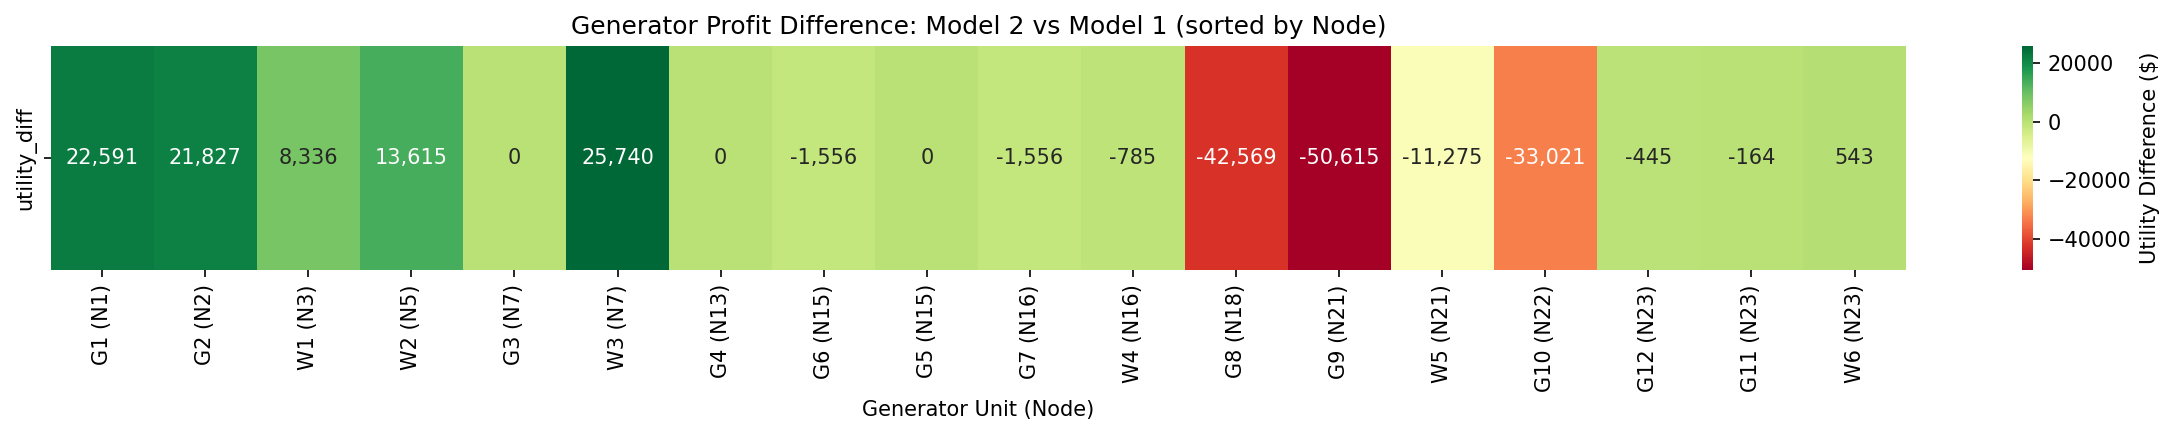

In [35]:
# show profit difference for generators as a heatmap sorted by node
plt.figure(figsize=(16, 3), dpi=150)

gen_diff_plot = gen_diff.copy()
gen_diff_plot['UnitNode'] = gen_diff_plot.apply(
    lambda r: f"{r['Unit']} (N{int(r['Node'])})" if pd.notna(r['Node']) else f"{r['Unit']} (N?)",
    axis=1
)

sns.heatmap(
    gen_diff_plot.set_index('UnitNode')[['utility_diff']].T,
    annot=True, fmt=',.0f', cmap='RdYlGn',
    cbar_kws={'label': 'Utility Difference ($)'}
)

plt.title('Generator Profit Difference: Model 2 vs Model 1 (sorted by Node)')
plt.xlabel('Generator Unit (Node)')
plt.ylabel('')
plt.tight_layout()
plt.show()

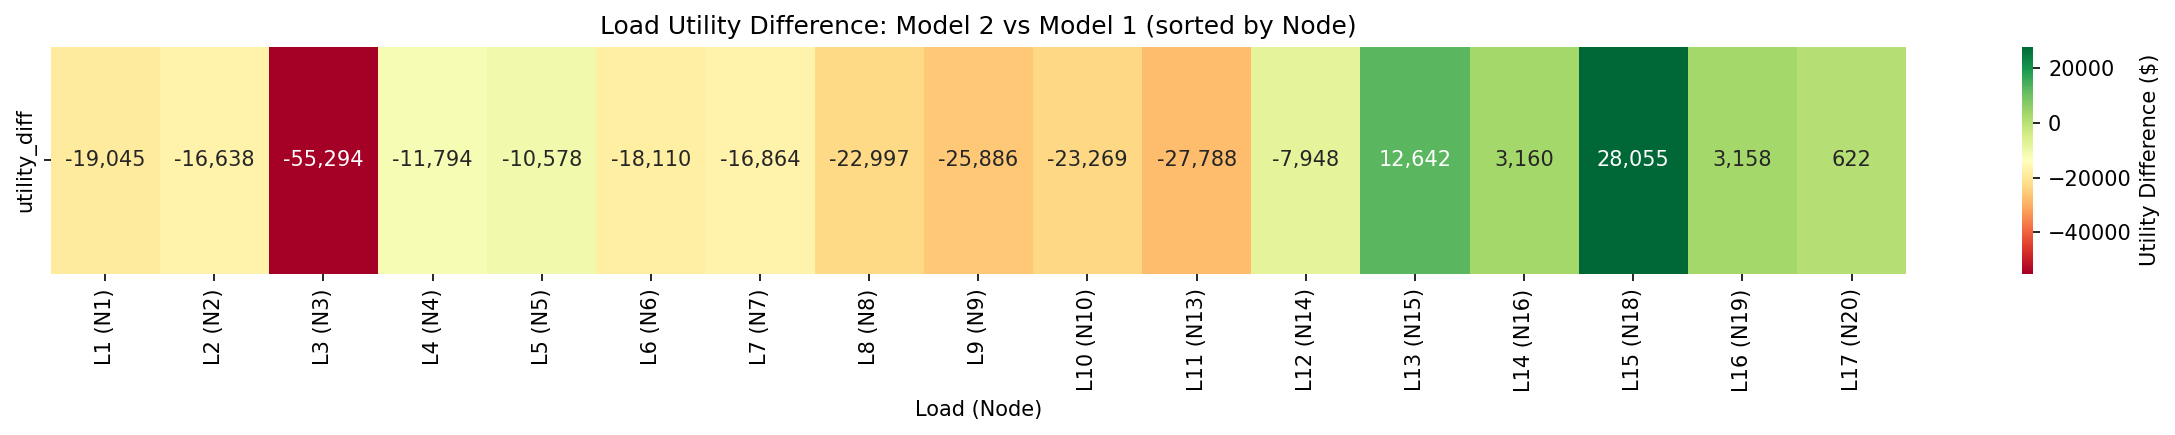

In [36]:
# show utility difference for loads as a heatmap sorted by node
plt.figure(figsize=(16, 3), dpi=150)

load_diff_plot = load_diff.copy()
load_diff_plot['LoadNode'] = load_diff_plot.apply(
    lambda r: f"{r['Load']} (N{int(r['Node'])})" if pd.notna(r['Node']) else f"{r['Load']} (N?)",
    axis=1
)

sns.heatmap(
    load_diff_plot.set_index('LoadNode')[['utility_diff']].T,
    annot=True, fmt=',.0f', cmap='RdYlGn',
    cbar_kws={'label': 'Utility Difference ($)'}
)

plt.title('Load Utility Difference: Model 2 vs Model 1 (sorted by Node)')
plt.xlabel('Load (Node)')
plt.ylabel('')
plt.tight_layout()
plt.show()

Although the overall social welfare is reduced by 36.4\%, there are some generators and some loads that are benefitted from the congestions. Loads located in the cheaper zone would increase their utility as well as generators located closer to the congestion, that are able to provide energy when there is congestion in the system. 

#### Nodal vs Zonal

In this section we will examine the profits of generators per zone, and estimate the price of redispatch due to internal constraints within the zone. 

First we will understand the violations occuring in model 3 That make the solution unfeasible. For this we will calculate the expected flow in each line using the PTDF and the net injections in each node as:

- Flow(line,hour) = sum_over_all_nodes of PTDF(node,line) * NetInjection(node,hour)

Then we can compare the expected flow with the line limits to see which lines are violated.

In [37]:
gen_m3 = model3.variables['p_gen'].solution.to_dataframe()
wf_gen_m3 = model3.variables['p_wind'].solution.to_dataframe()
demand_m3 = model3.variables['p_demand'].solution.sum(dim='Bid').to_dataframe()

# Assign node to each generator 
gen_m3 = gen_m3.reset_index().merge(gen_constraints[['Unit', 'Node']].drop_duplicates(), on='Unit', how='left')
wf_gen_m3 = wf_gen_m3.reset_index().merge(wind_forecast_generation[['Unit', 'Node']].drop_duplicates(), on='Unit', how='left')
demand_m3 = demand_m3.reset_index().merge(demand_bid[['Load', 'Node']].drop_duplicates(), on='Load', how='left')
demand_m3['solution'] = - demand_m3['solution']

solution_df = pd.concat([gen_m3,wf_gen_m3,demand_m3.rename(columns={'Load':'Unit'})], ignore_index=True)
solution_df = solution_df.groupby(['Node','Hour'])['solution'].sum().reset_index()
solution_df.rename(columns={'solution': 'NetInjection_MW'}, inplace=True)

# fill missing nodes with zero injection
all_nodes_hours = pd.MultiIndex.from_product([range(1,25), range(24)], names=['Node', 'Hour'])
solution_df = solution_df.set_index(['Node', 'Hour']).reindex(all_nodes_hours, fill_value=0).reset_index()


injection = solution_df.pivot(index='Hour', columns='Node', values='NetInjection_MW')
# set injection at slack bus (node 13) to zero for all hours
injection[13] = 0

injection_np = injection.to_numpy()
ptdf_np = ptdf.to_numpy()

flows_m3 = ptdf @ injection_np.T

# Max capacity as a matrix of (lines, hours)
max_cap = lines_modified.set_index('Line')['Capacity_MVA'].to_numpy()
max_cap_matrix = np.tile(max_cap[:, np.newaxis], (1, 24))

# elementwise min between each matrix element and 0
violations = np.minimum(max_cap_matrix - np.abs(flows_m3), 0)

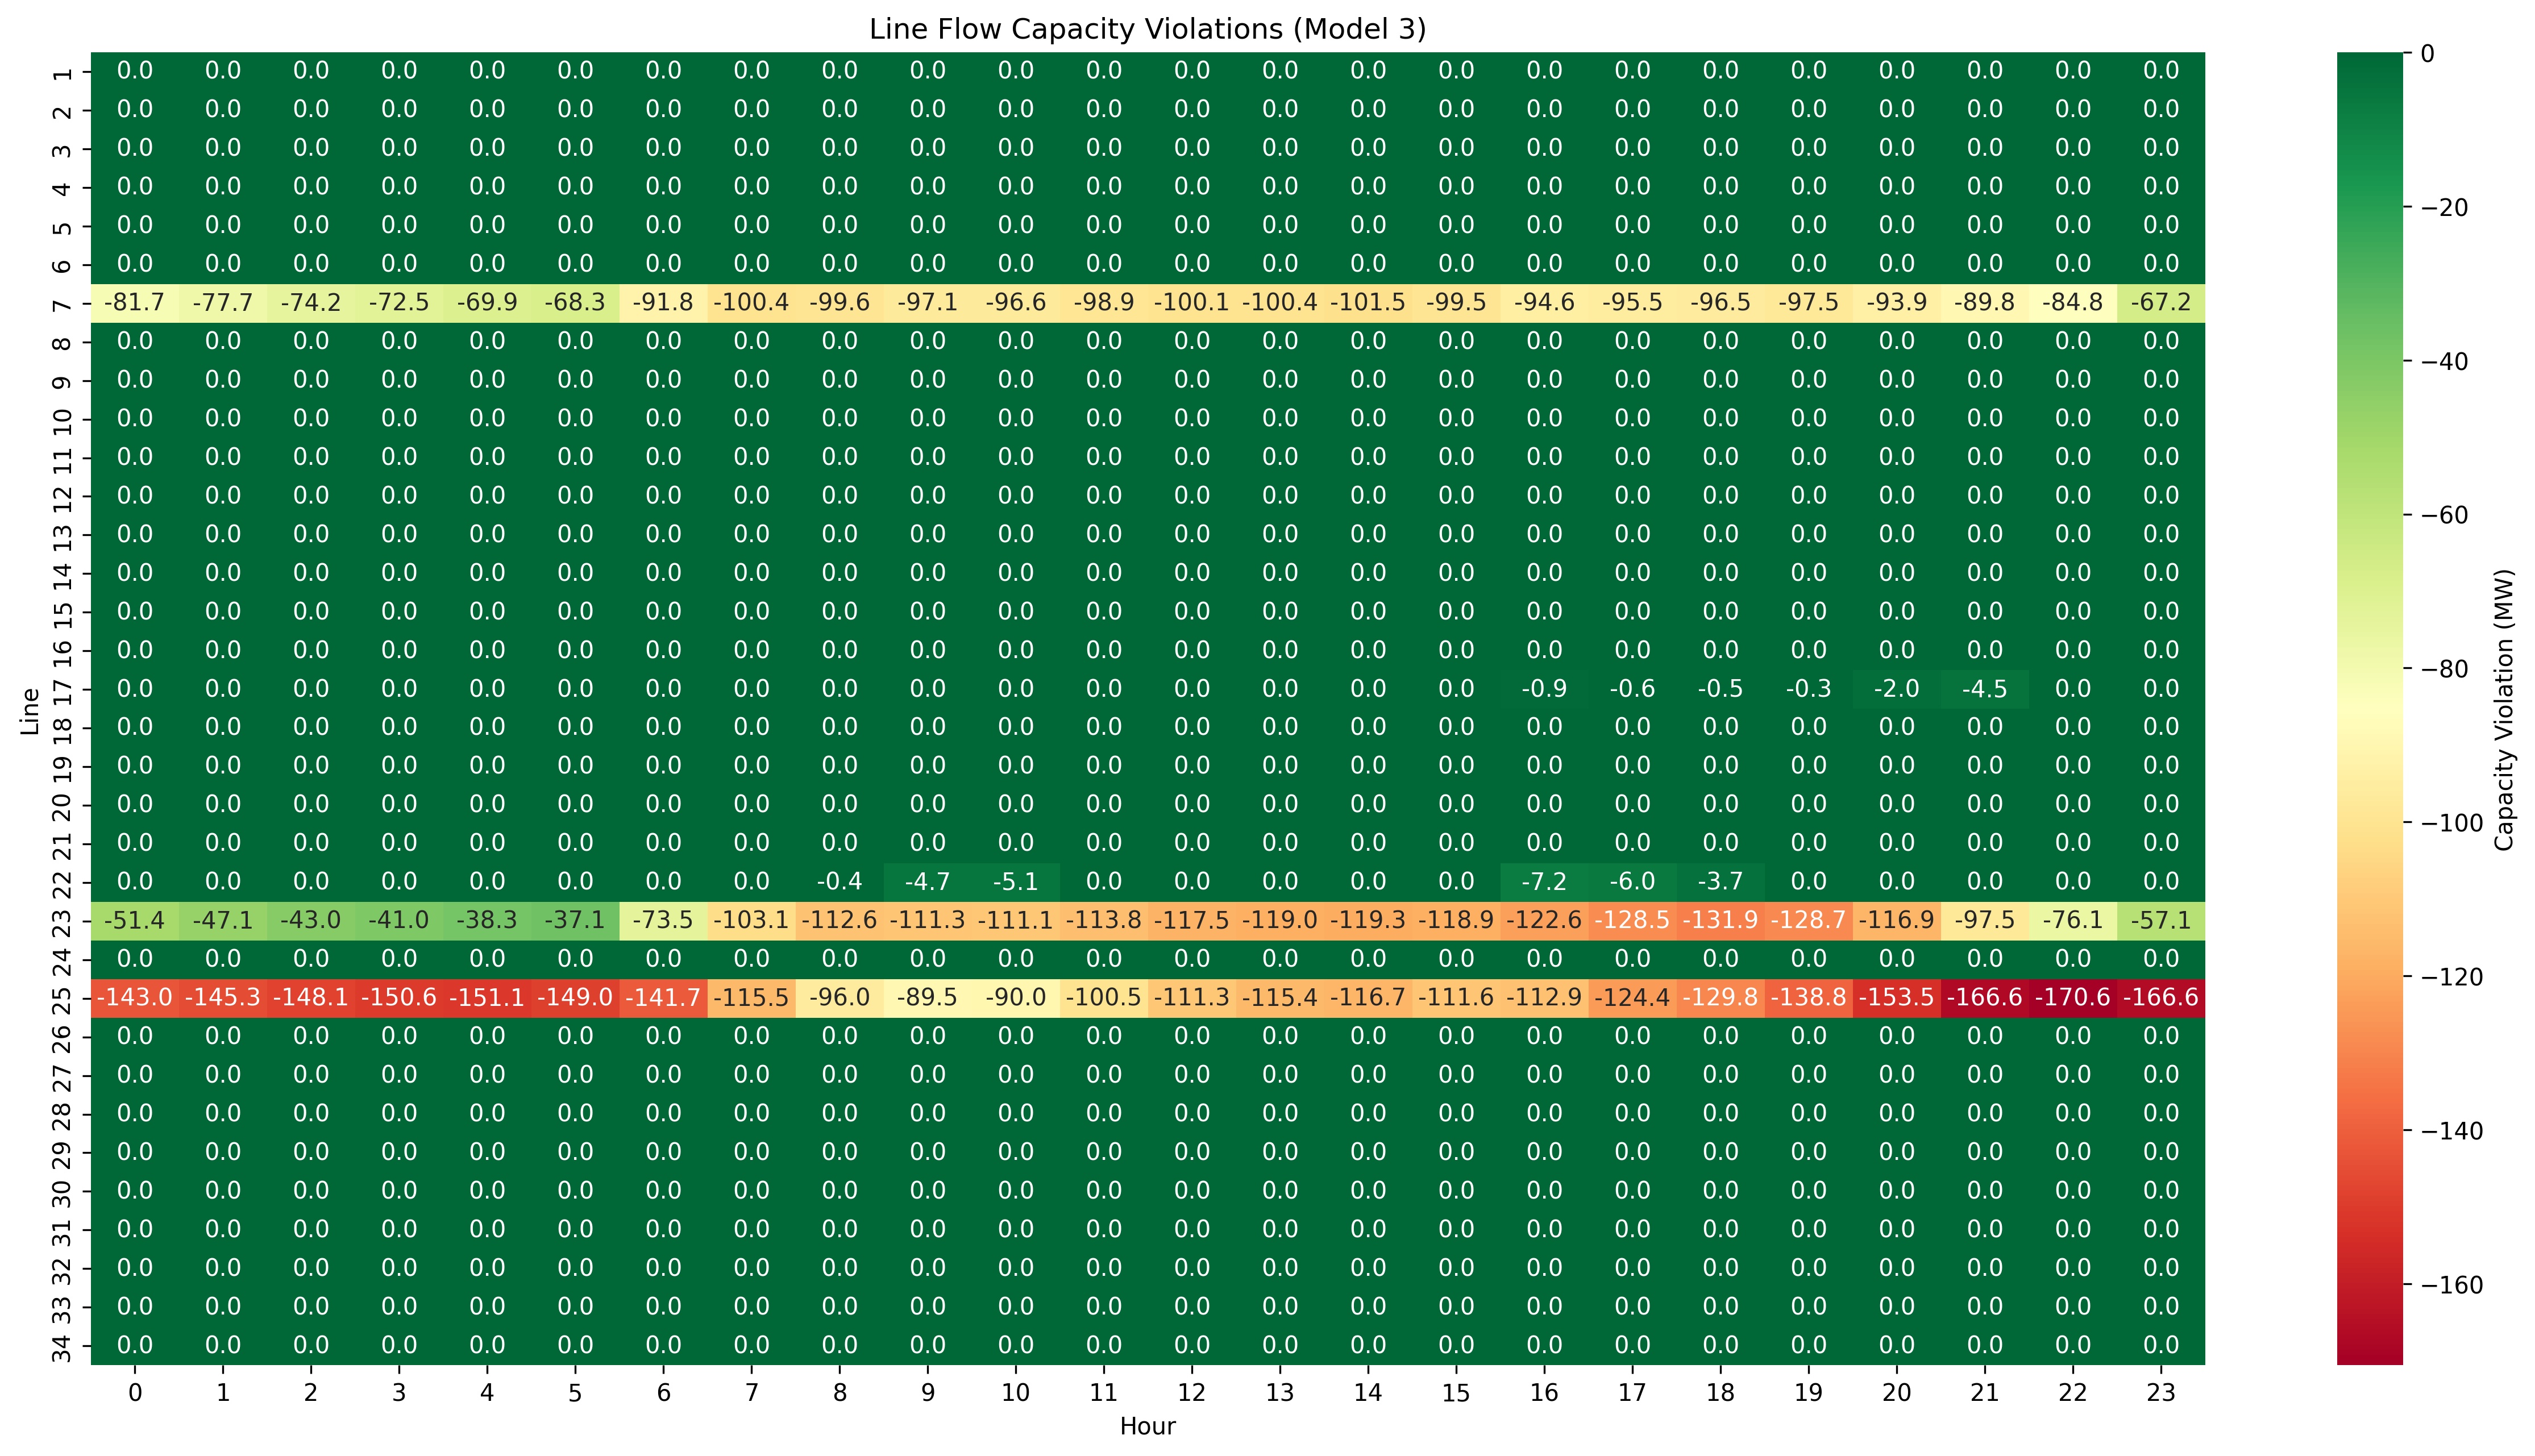

In [38]:
# heatmap with violations
plt.figure(figsize=(20, 10), dpi=300)
sns.heatmap(violations, annot=True, fmt='.1f', cmap='RdYlGn', cbar_kws={'label': 'Capacity Violation (MW)'})
plt.title('Line Flow Capacity Violations (Model 3)')
plt.xlabel('Hour')
plt.ylabel('Line')
plt.show()

To estimate the cost of redispatch we assume that the new solution would be similar to the one of model 2. With that we can find the generators that have to be curtailed and the ones that have to increase their generation to make the solution feasible. 

Then we assume that the compensation for curtailment is 0 and the compensation for increase demand is paid at the cost of production of the generator.  

In [39]:
gen_m3 = model3.variables['p_gen'].solution.to_dataframe()
wf_gen_m3 = model3.variables['p_wind'].solution.to_dataframe()

generation_m3 = pd.concat([gen_m3, wf_gen_m3])

gen_m2 = model2.variables['p_gen'].solution.to_dataframe()
wf_gen_m2 = model2.variables['p_wind'].solution.to_dataframe()
generation_m2 = pd.concat([gen_m2, wf_gen_m2])

redispatch_sol = (generation_m2['solution'] - generation_m3['solution']).reset_index()

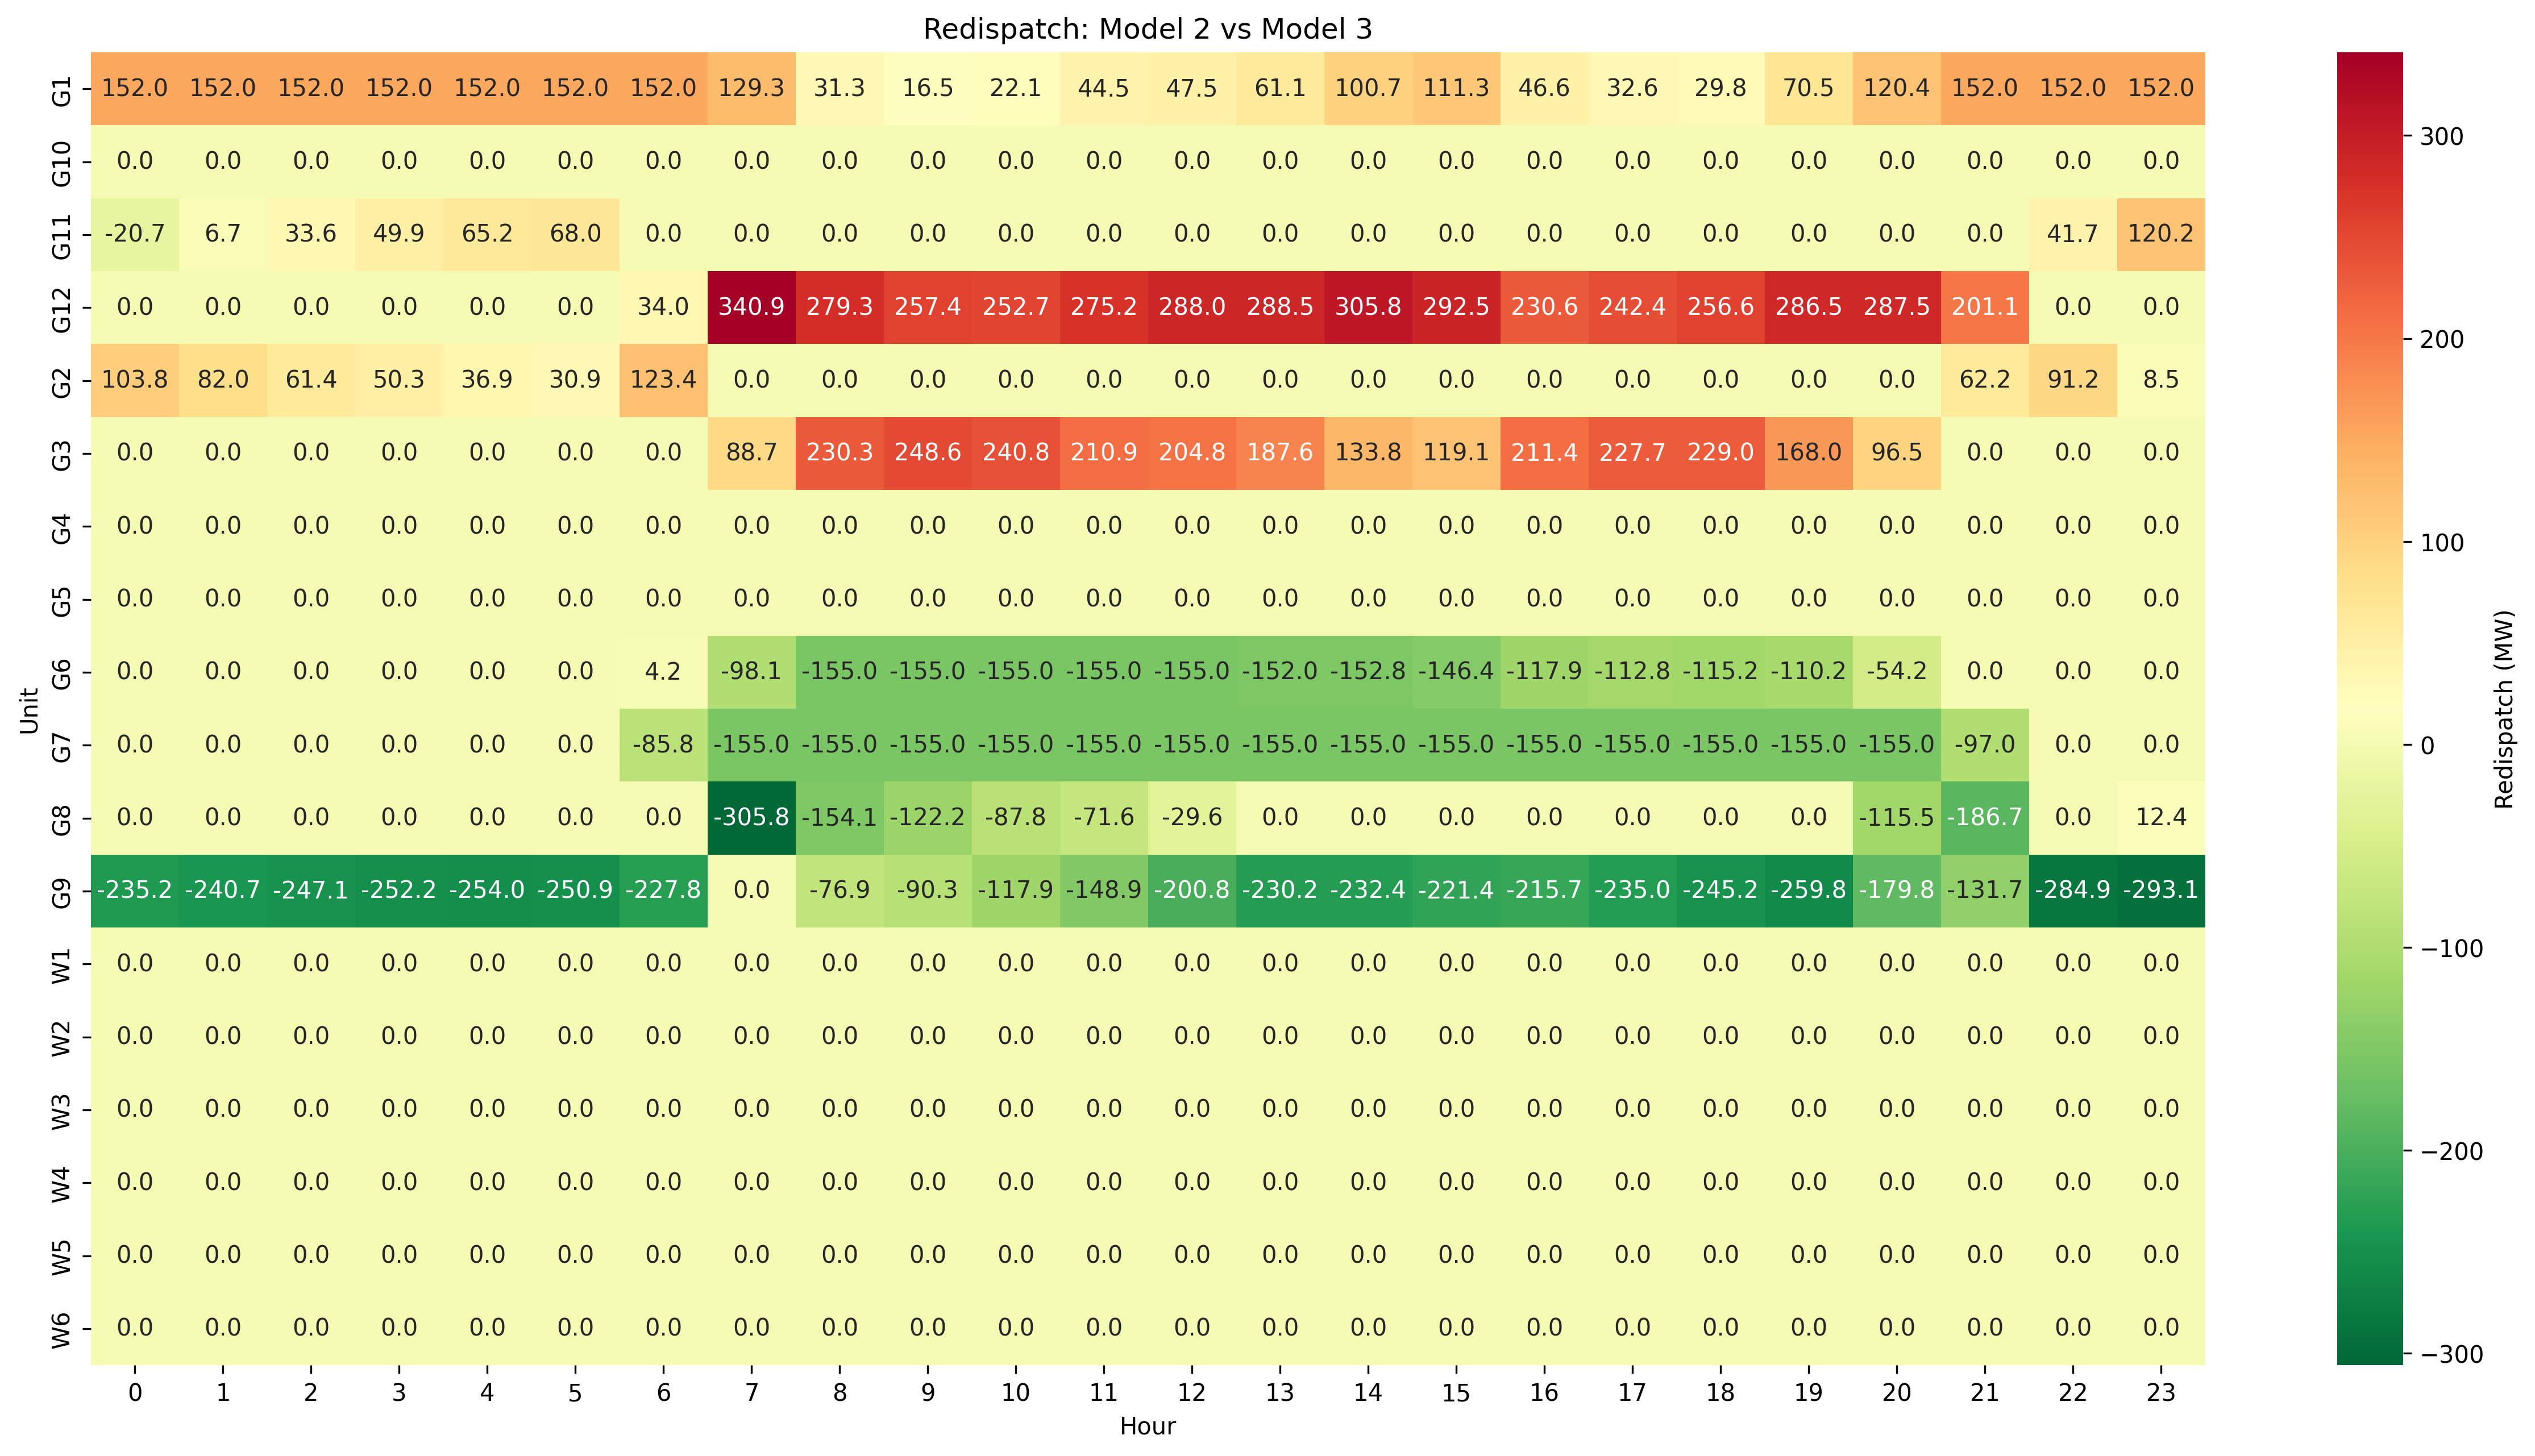

In [40]:
# plot redispatch
redispatch_pivot = redispatch_sol.pivot(index='Unit', columns='Hour', values='solution').fillna(0)
plt.figure(figsize=(20, 10), dpi=300)
sns.heatmap(redispatch_pivot, annot=True, fmt='.1f', cmap='RdYlGn_r', cbar_kws={'label': 'Redispatch (MW)'})
plt.title('Redispatch: Model 2 vs Model 3')
plt.xlabel('Hour')
plt.ylabel('Unit')
plt.show()

In [41]:
redispatch = redispatch_sol.merge(gen_constraints[['Unit', 'Ci_$/MWh','Node']], on='Unit', how='left') 
redispatch['Ci_$/MWh'] = redispatch['Ci_$/MWh'].fillna(0)  # assume zero variable cost for wind farms
redispatch['Redispatch_cost'] = np.where(redispatch['solution'] > 0, redispatch['solution'] * redispatch['Ci_$/MWh'], 0)


# Curtailment cost
lmp_model3 = {name.replace('balance_zone', 'Zone '): constraint.dual.to_numpy() for name, constraint in model3.constraints.items() if name.startswith('balance_zone')}
lmp_m3_df = pd.DataFrame(lmp_model3).reset_index(names='Hour').melt(id_vars='Hour', var_name='Zone', value_name='LMP')
redispatch['Zone'] = np.where(redispatch['Node'] <= 10, 'Zone 1', 'Zone 2')
redispatch = redispatch.merge(lmp_m3_df, on=['Hour','Zone'], how='left')
redispatch['Curtailment_cost'] = np.where(redispatch['solution'] < 0, - redispatch['solution'] * redispatch['LMP'], 0)

In [43]:
redispatch_total_cost = redispatch['Redispatch_cost'].sum()
curtailment_cost = redispatch['Curtailment_cost'].sum()

print(f"The additional cost for redispatch in Model 3 (payment for additional generation): {redispatch_total_cost:,.2f} $")
print(f"Social welfare for model 3 considering cost of redispatch: {-model3.objective.value - redispatch_total_cost:,.2f} $")
print(f"Recall: Social welfare for Model 2: {-model2.objective.value:,.2f}")

print(f"\nIncluded in this loss of efficiency is the additional payment to curtail generators, that is valuated in: {curtailment_cost:,.2f} $")

The additional cost for redispatch in Model 3 (payment for additional generation): 143,214.66 $
Social welfare for model 3 considering cost of redispatch: 90,846,488.66 $
Recall: Social welfare for Model 2: 90,923,865.70

Included in this loss of efficiency is the additional payment to curtail generators, that is valuated in: 107,620.49 $
